# Pancreas SingleScorer tutorial

This notebook is a complete guide to one supervised pancreas analysis. It starts
with the original scVelo manifold and finishes with interpretable scCS outputs,
downstream biological context, sensitivity analysis, and reproducible export.

The scientific quantities are kept separate throughout:

- **future-fate affinity**: conditional identity among the supplied fates;
- **future-fate reach**: discounted probability of reaching a supplied endpoint;
- **future-fate specificity**: decisiveness among the supplied fates;
- **reach-supported specificity**: fate decisiveness weighted by reach;
- **signed progression**: forward, retrograde, or mixed movement along the supplied ordering.

Alpha, Delta, and Epsilon are not required to form simple monotonic rays. Their
unusual native velocity patterns are biological results to interpret, not errors
that scCS should erase.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and reproducibility


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/pancreas_single")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


## 2. Load pancreas and fit dynamical RNA velocity

Neighbors, moments, kinetic fitting, velocity, and the velocity graph are computed
in the original PCA/expression manifold. The supervised star is not used to create
neighborhoods or refit velocity.

This tutorial deliberately starts from the public dataset and recomputes the
velocity model. No pre-existing scCS cache is assumed. Dynamical fitting can
take several minutes, but showing the complete preparation makes every analysis
step reproducible for a first-time user.



In [2]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [3]:
RECOVER_DYNAMICS_MAX_ITER = 20

# Load the public scVelo pancreas dataset.
adata = scv.datasets.pancreas()
adata.var_names_make_unique()

# Fit RNA velocity in the original expression/PCA manifold.
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
)
clear_velocity_outputs(adata, clear_dynamics=True)

# Dynamical velocity is used because the pancreas dataset contains several
# kinetic regimes and non-monotonic terminal trajectories.
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
scv.tl.terminal_states(adata)
scv.tl.latent_time(
    adata,
    vkey="velocity",
    root_key="root_cells",
    end_key="end_points",
)
scv.tl.velocity_pseudotime(adata, vkey="velocity")

print(adata)
display(adata.obs["clusters"].astype(str).value_counts().to_frame("n_cells"))

try downloading from url
https://github.com/theislab/scvelo_notebooks/raw/master/data/Pancreas/endocrinogenesis_day15.h5ad
... this may take a while but only happens once
creating directory data/Pancreas/ for saving data


  0%|          | 0.00/50.0M [00:00<?, ?B/s]

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:06)
computing moments based on connectivities
    finished (0:00:01)
recovering dynamics (using 1/24 cores)


  0%|          | 0/2722 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=91172) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:26:44)
computing velocities
    finished (0:00:07)
computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=91172) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:19)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00)
computing latent time using root_cells, end_points as prior
    finished (0:00:04)
AnnData object with n_obs × n_vars = 3696 × 7197
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'highly_variable_genes', 'gene_count_corr', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap'


,n_cells
clusters,
Ductal,916
Ngn3 high EP,642
Pre-endocrine,592
Beta,591
Alpha,481
Ngn3 low EP,262
Epsilon,142
Delta,70


## 3. Inspect native annotations, ordering candidates, and the velocity field


latent_time                               velocity_pseudotime  \
                    count    median       min       max               count   
clusters                                                                      
Ngn3 high EP          642  0.538150  0.197135  0.668318                 642   
Pre-endocrine         592  0.719086  0.544826  0.767974                 592   
Beta                  591  0.728306  0.690814  1.000000                 591   
Alpha                 481  0.745250  0.704222  0.797031                 481   
Delta                  70  0.785738  0.693870  0.841107                  70   
Epsilon               142  0.740098  0.697535  0.758869                 142   

                                             
                 median       min       max  
clusters                                     
Ngn3 high EP   0.439079  0.116273  0.632564  
Pre-endocrine  0.814839  0.497939  0.914136  
Beta           0.883505  0.835416  1.000000  
Alpha          0.909996  0.830502  0.920302  
Delta          0.918165  0.904303  0.926678  
Epsilon        0.908112  0.863491  0.913667

computing velocity embedding
    finished (0:00:00)


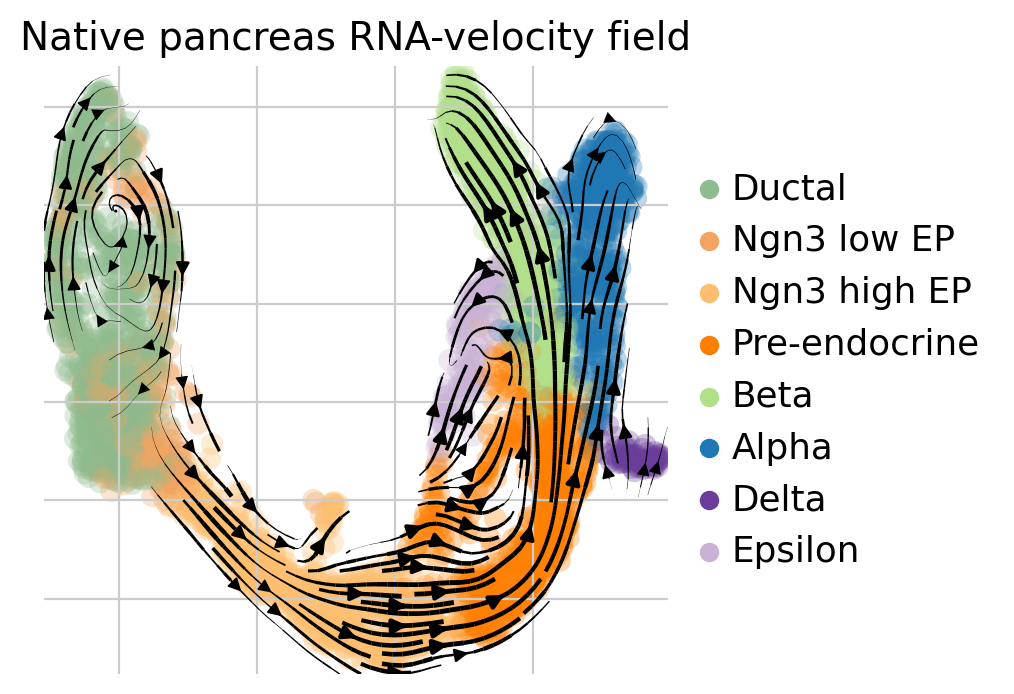

In [4]:
selected_labels = [
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]
selected_mask_full = adata.obs["clusters"].astype(str).isin(selected_labels)
ordering_columns = [key for key in ("latent_time", "velocity_pseudotime") if key in adata.obs]
display(
    adata.obs.loc[selected_mask_full, ["clusters", *ordering_columns]]
    .groupby("clusters", observed=True)
    .agg(["count", "median", "min", "max"])
)

scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color="clusters",
    legend_loc="right margin",
    title="Native pancreas RNA-velocity field",
)

## 4. Define the supervised furcation and run preflight diagnostics

The incoming path contains both `Ngn3 high EP` and `Pre-endocrine` because the
earlier progenitor state is required to represent the complete approach to the
endocrine furcation. Dynamical latent time is used for the scientific ordering.


In [5]:
ROOT = ("Ngn3 high EP", "Pre-endocrine")
FATES = ["Alpha", "Beta", "Delta", "Epsilon"]
ORDERING_KEY = "latent_time"

scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="clusters",
)
preflight = scorer.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()

scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,2518.0
1,info,root_cells,Root population contains 1234 cells.,1234.0
2,info,terminal_Alpha,Terminal 'Alpha' contains 481 cells.,481.0
3,info,terminal_Beta,Terminal 'Beta' contains 591 cells.,591.0
4,info,terminal_Delta,Terminal 'Delta' contains 70 cells.,70.0
5,info,terminal_Epsilon,Terminal 'Epsilon' contains 142 cells.,142.0
6,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.0
7,info,ordering_resolution,Root ordering has 1234 unique values across 12...,1.0
8,info,velocity_available,Velocity information is available.,NaN


[scCS] Scientific star built for 2518 cells in 4 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).


## 5. Fit the primary discounted future-fate model


In [6]:
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
    "committed_reach_threshold": 0.25,
    "committed_specificity_threshold": 0.25,
}

scorer.fit(
    scoring_mode="future_fate",
    future_fate_options=FUTURE_OPTIONS,
)
result = scorer.score(write_to_adata=True)

display(pd.Series(result.summary(), name="value").to_frame())
anchor_diagnostics = result.anchor_diagnostics_frame()
display(anchor_diagnostics)
anchor_diagnostics.to_csv(OUTPUT_DIR / "anchor_diagnostics.csv", index=False)

scCS FutureFateScoreResult
  Furcation: root -> ['Alpha', 'Beta', 'Delta', 'Epsilon']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 2518 selected; 1234 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.624
  Root mean future-fate entropy: 0.597
  Root mean future-fate specificity: 0.403
  Root mean reach-supported specificity: 0.254
  Root mean unresolved probability: 0.376
  Root mean signed progression: 0.041
  Root future-fate composition: Alpha=0.291, Beta=0.630, Delta=0.000, Epsilon=0.079
  Solver: direct; iterations=1; residual=1.927e-15
scCS FutureFateScoreResult
  Furcation: root -> ['Alpha', 'Beta', 'Delta', 'Epsilon']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 2518 selected; 1234 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.624
  Root mean future-fate entropy: 0.597
  Root mean future-fate specificity: 0.403
  Root mean reach-supported specificity: 0.254
  Root mean unresolved probability: 0.376
  Root mean signed progre

,value
0,scCS FutureFateScoreResult\n Furcation: root ...


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Alpha,49,0.998604,0.000101,0.001295,0.0,-0.039809,0.000000
1,Beta,60,1.000000,0.000000,0.000000,0.0,-0.009623,0.033333
2,Delta,10,0.857701,0.000722,0.141577,0.0,-0.042991,0.000000
3,Epsilon,15,0.686047,0.198733,0.115220,0.0,-0.098604,0.000000


## 6. Core star dashboard

All panels use identical cell positions. The star is a standardized display, not
an inverse map of UMAP or gene space. The one-step selected-path coverage panel is
a graph-scope diagnostic and should not be interpreted as commitment.


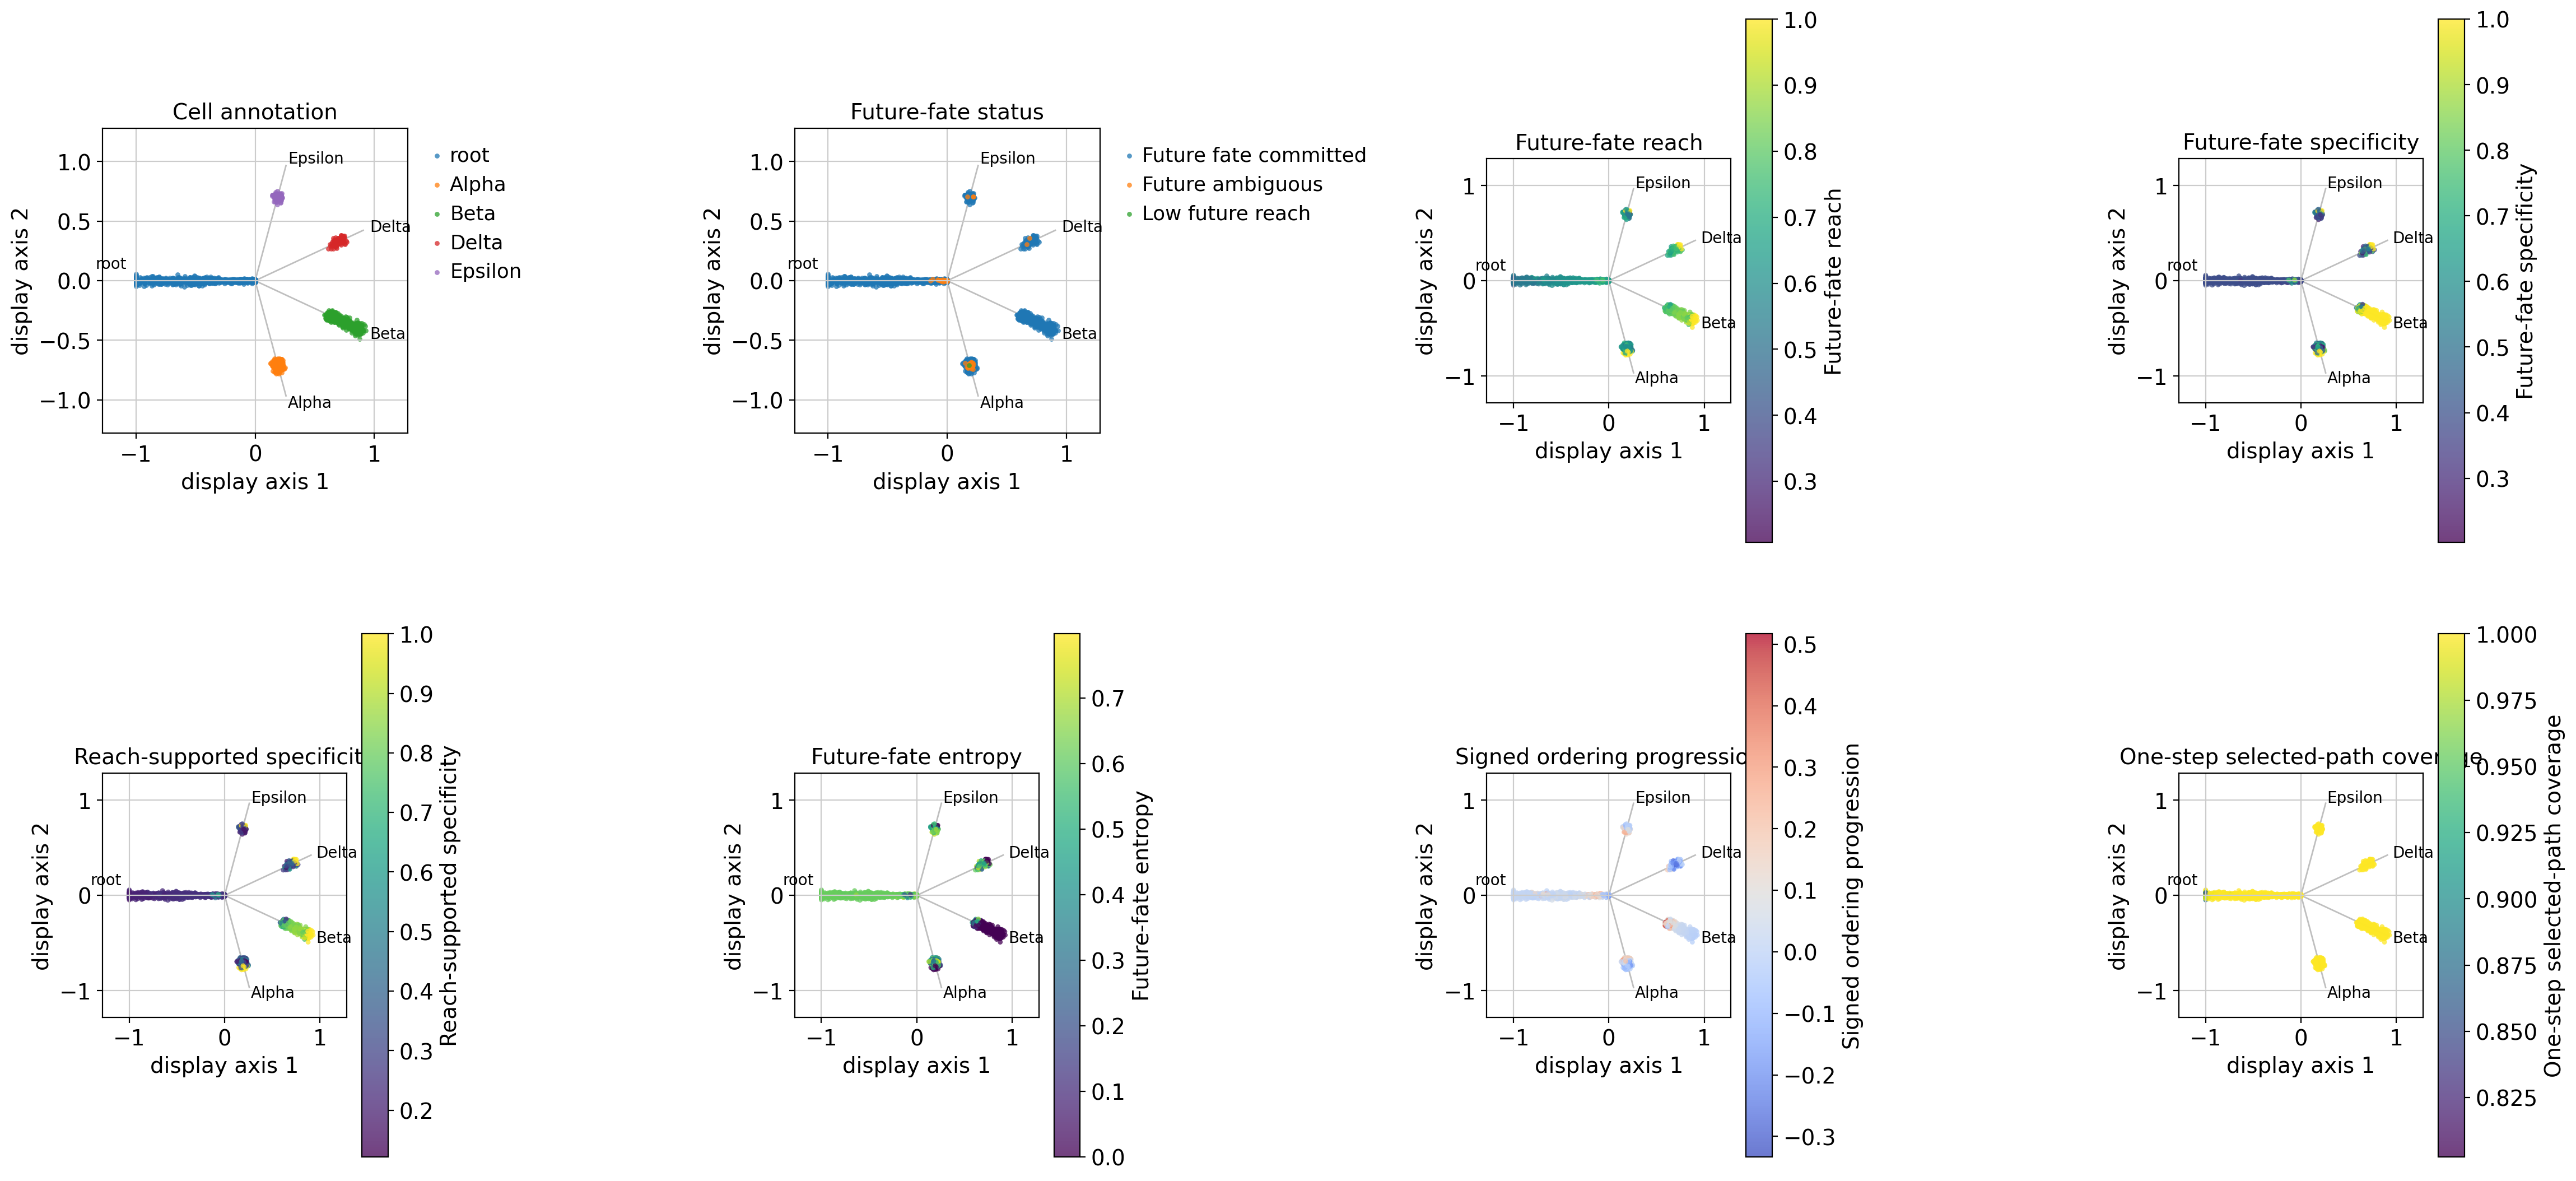

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(23, 11))
scorer.plot_star(result, color_by="population", title="Cell annotation", ax=axes[0, 0])
scorer.plot_star(result, color_by="status", title="Future-fate status", ax=axes[0, 1])
scorer.plot_star(result, color_by="future_fate_reach", title="Future-fate reach", ax=axes[0, 2])
scorer.plot_star(
    result,
    color_by="future_fate_specificity",
    title="Future-fate specificity",
    ax=axes[0, 3],
)
scorer.plot_star(
    result,
    color_by="reach_supported_specificity",
    title="Reach-supported specificity",
    ax=axes[1, 0],
)
scorer.plot_star(result, color_by="future_fate_entropy", title="Future-fate entropy", ax=axes[1, 1])
scorer.plot_star(
    result,
    color_by="signed_progression",
    title="Signed ordering progression",
    cmap="coolwarm",
    ax=axes[1, 2],
)
scorer.plot_star(
    result,
    color_by="selected_path_coverage",
    title="One-step selected-path coverage",
    ax=axes[1, 3],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "core_star_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Fate-specific affinity and absolute contribution


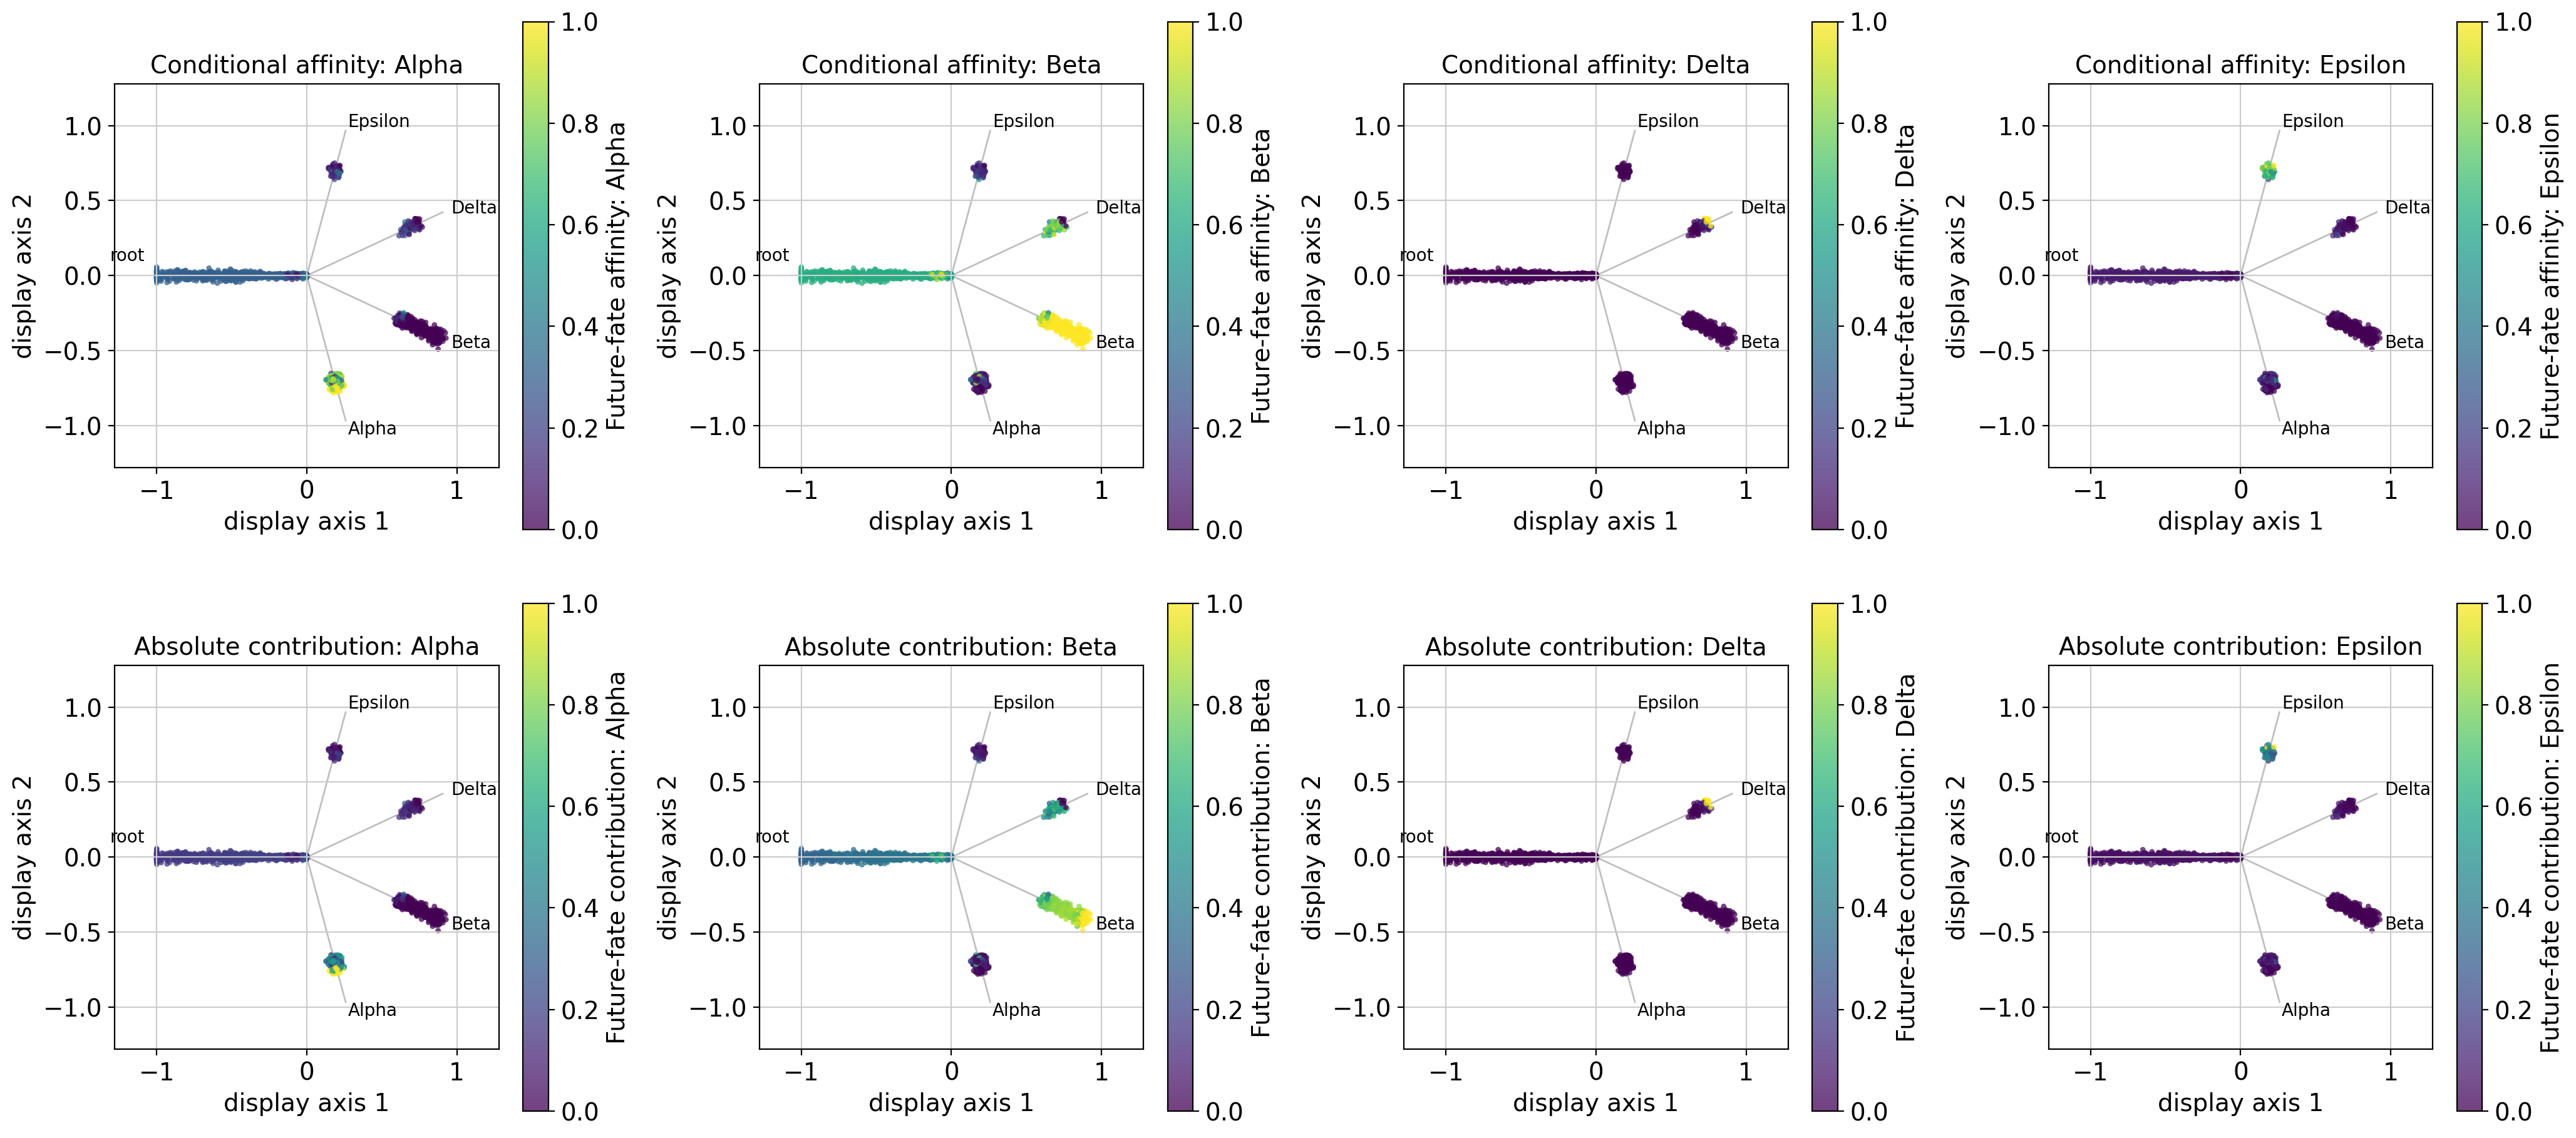

In [8]:
fig, axes = plt.subplots(2, len(FATES), figsize=(5.2 * len(FATES), 9.5))
for column, fate in enumerate(FATES):
    scorer.plot_star(
        result,
        color_by=f"future_fate_affinity:{fate}",
        title=f"Conditional affinity: {fate}",
        ax=axes[0, column],
    )
    scorer.plot_star(
        result,
        color_by=f"future_fate_contribution:{fate}",
        title=f"Absolute contribution: {fate}",
        ax=axes[1, column],
    )
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fate_affinity_and_contribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Cell-level heatmaps with annotation strips


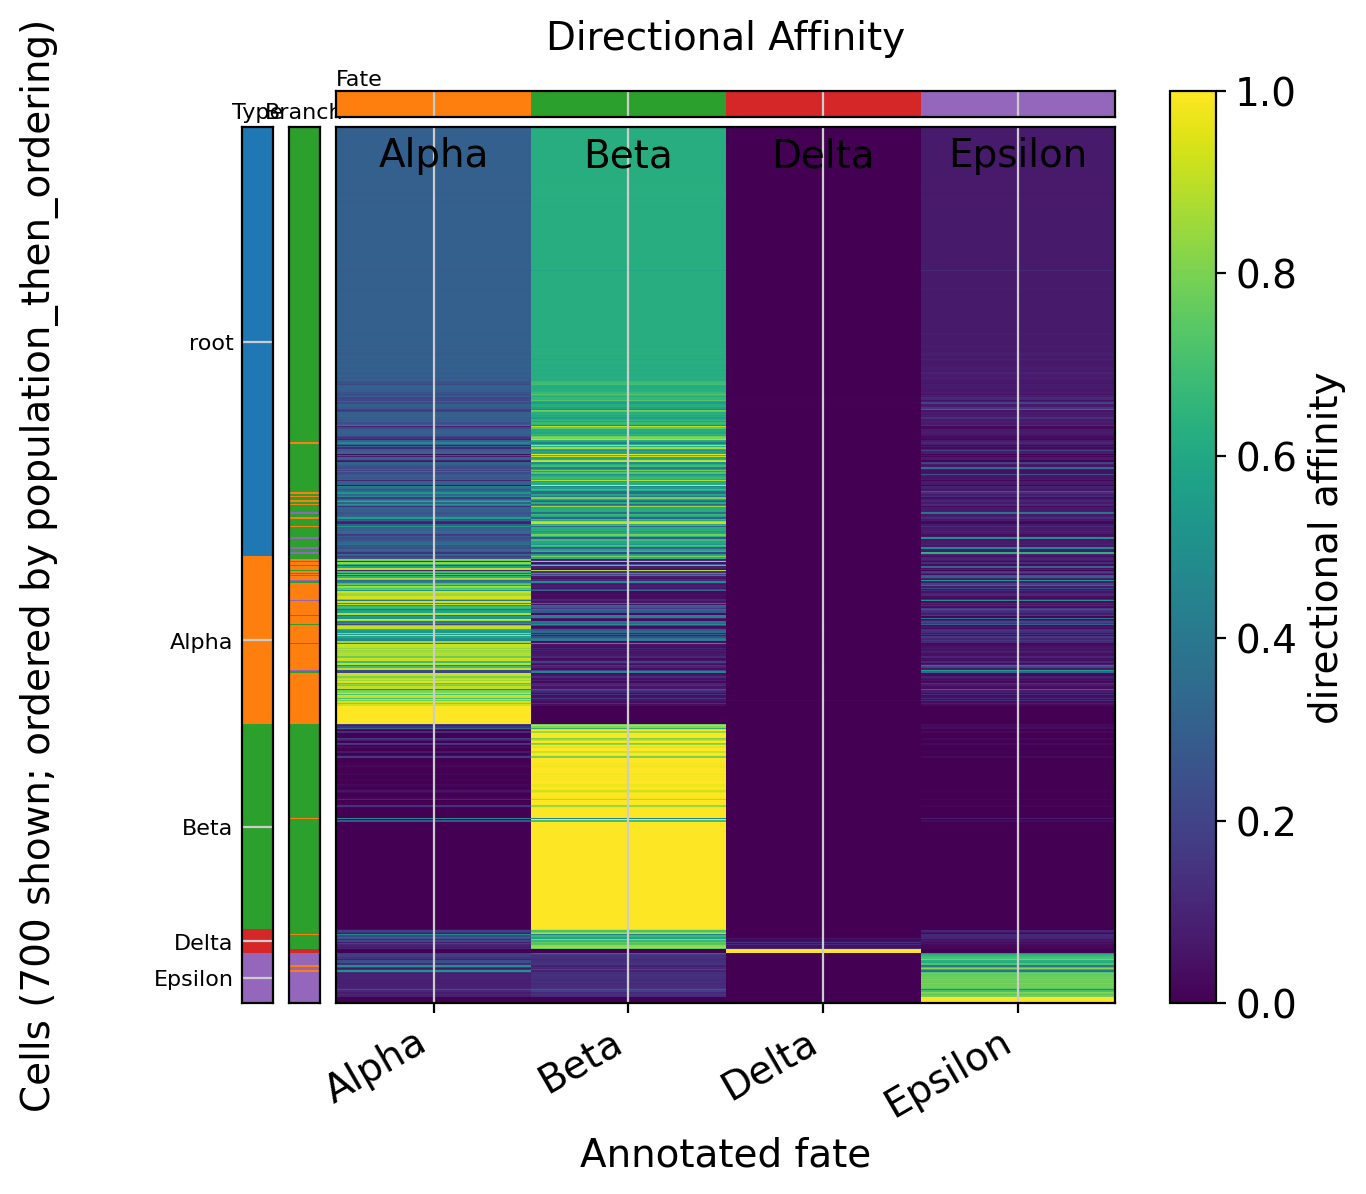

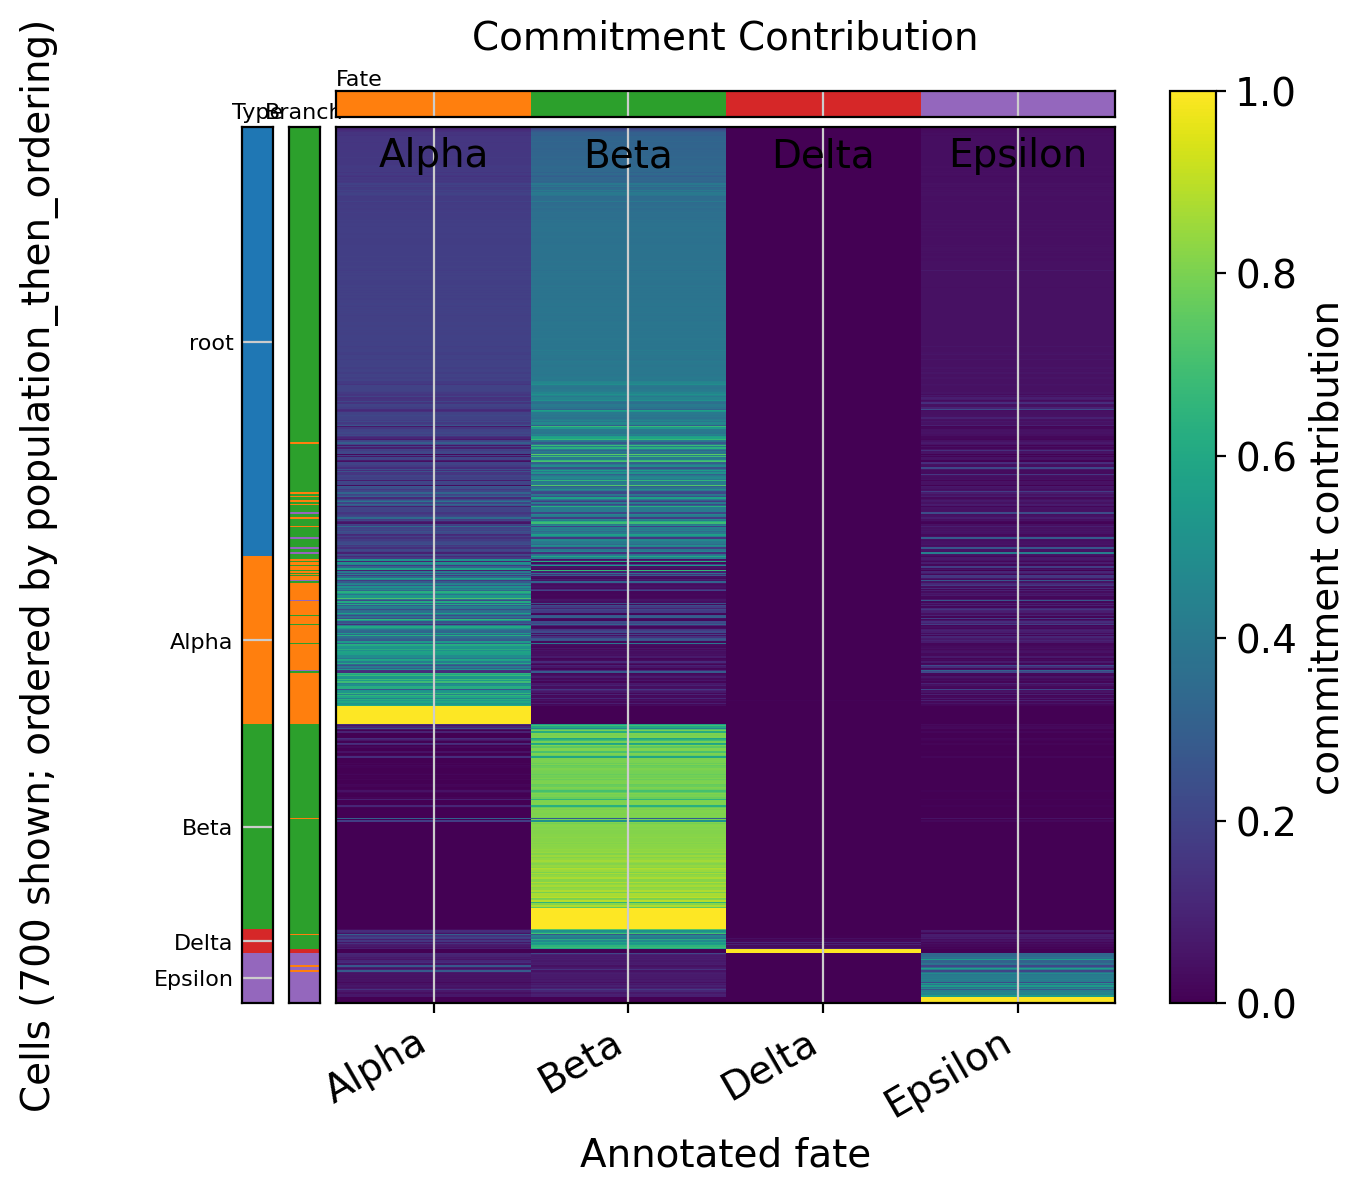

In [9]:
affinity_fig = scorer.plot_commitment_heatmap(
    result,
    metric="future_fate_affinity",
    population="all",
    sort_by="population_then_ordering",
    row_annotation=("population", "dominant_affinity"),
    show_fate_strip=True,
    max_cells=700,
)
affinity_fig.savefig(OUTPUT_DIR / "future_fate_affinity_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

contribution_fig = scorer.plot_commitment_heatmap(
    result,
    metric="future_fate_contribution",
    population="all",
    sort_by="population_then_ordering",
    row_annotation=("population", "dominant_affinity"),
    show_fate_strip=True,
    max_cells=700,
)
contribution_fig.savefig(
    OUTPUT_DIR / "future_fate_contribution_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 9. Population summaries, fate composition, and pairwise balance


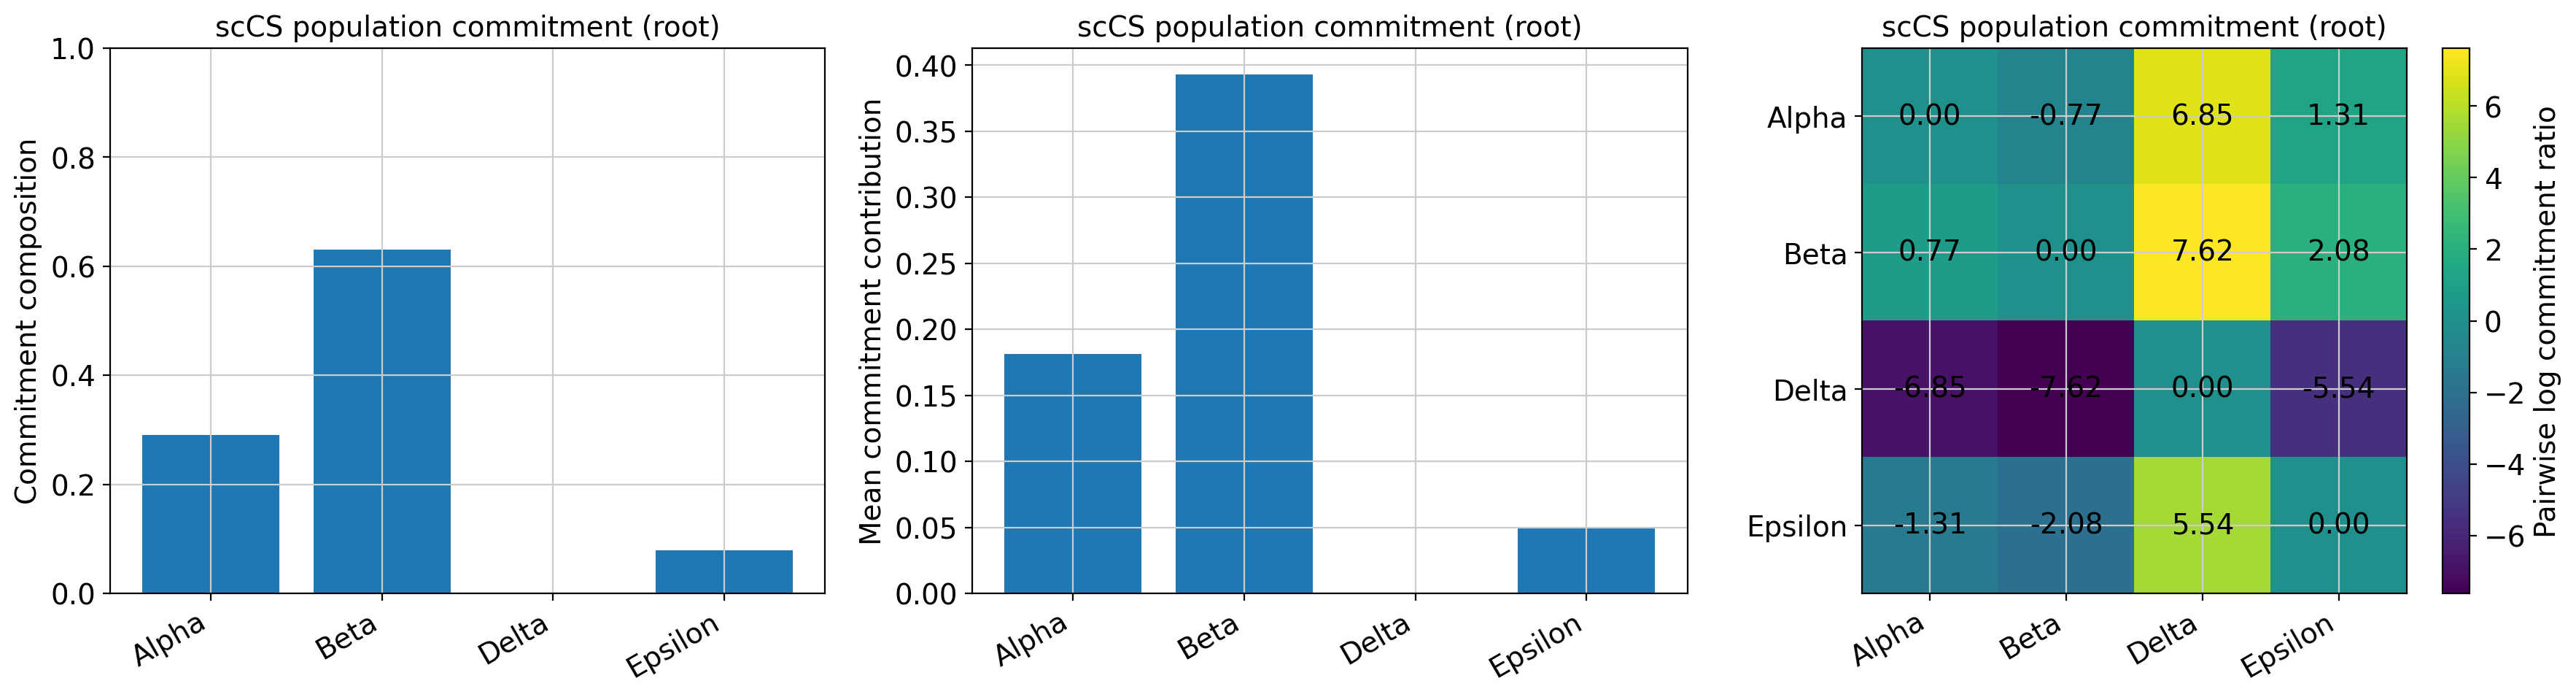

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scorer.plot_commitment_bar(
    result,
    population="root",
    metric="commitment_composition",
    ax=axes[0],
)
scorer.plot_population_commitment(
    result,
    population="root",
    metric="mean_commitment_contribution",
    ax=axes[1],
)
scorer.plot_pairwise_cs(result, population="root", ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "root_population_summaries.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Branch behavior and ordering thirds

A branch can retain strong fate identity while signed progression turns negative.
This is particularly important for the curved Alpha path and the unusual Delta and
Epsilon velocity fields.


In [11]:
selected = adata.obs.loc[result.cell_ids].copy()
selected["future_fate_reach"] = result.future_fate_reach
selected["future_fate_specificity"] = result.future_fate_specificity
selected["reach_supported_specificity"] = result.reach_supported_specificity
selected["signed_progression"] = result.signed_progression
selected["ordering_third"] = ordering_thirds(selected[ORDERING_KEY].to_numpy(float))
for fate_index, fate in enumerate(FATES):
    selected[f"affinity_{fate}"] = result.future_fate_affinity[:, fate_index]
    selected[f"contribution_{fate}"] = result.future_fate_contribution[:, fate_index]

population_summary = selected.groupby("clusters", observed=True).agg(
    n_cells=("future_fate_reach", "size"),
    mean_reach=("future_fate_reach", "mean"),
    mean_specificity=("future_fate_specificity", "mean"),
    mean_supported_specificity=("reach_supported_specificity", "mean"),
    mean_progression=("signed_progression", "mean"),
    forward_fraction=("signed_progression", lambda values: float(np.mean(values > 0))),
)
display(population_summary)
population_summary.to_csv(OUTPUT_DIR / "population_summary.csv")

branch_thirds = (
    selected[selected["clusters"].astype(str).isin(FATES)]
    .groupby(["clusters", "ordering_third"], observed=True)
    .agg(
        n_cells=("future_fate_reach", "size"),
        mean_reach=("future_fate_reach", "mean"),
        mean_specificity=("future_fate_specificity", "mean"),
        mean_progression=("signed_progression", "mean"),
        forward_fraction=("signed_progression", lambda values: float(np.mean(values > 0))),
    )
)
display(branch_thirds)
branch_thirds.to_csv(OUTPUT_DIR / "branch_ordering_thirds.csv")

,n_cells,mean_reach,mean_specificity,mean_supported_specificity,mean_progression,forward_fraction
clusters,,,,,,
Ngn3 high EP,642,0.586236,0.389054,0.228086,0.033081,0.968847
Pre-endocrine,592,0.665058,0.417348,0.281243,0.048918,0.645270
Beta,591,0.821739,0.931207,0.771859,0.096513,0.844332
Alpha,481,0.661622,0.594197,0.411253,0.003379,0.446985
Delta,70,0.769183,0.557608,0.450258,-0.134738,0.071429
Epsilon,142,0.617827,0.500247,0.332878,0.023334,0.584507


n_cells  mean_reach  mean_specificity  \
clusters ordering_third                                          
Beta     early                11    0.745487          0.658780   
         late                282    0.869033          0.999996   
         middle              298    0.779799          0.876167   
Alpha    late                306    0.682022          0.636212   
         middle              175    0.625950          0.520729   
Delta    early                 1    0.686064          0.391010   
         late                 60    0.780078          0.569959   
         middle                9    0.705788          0.493782   
Epsilon  early                 1    0.658172          0.271163   
         late                 78    0.651685          0.566368   
         middle               63    0.575268          0.422019   

                         mean_progression  forward_fraction  
clusters ordering_third                                      
Beta     early                   0.143923          1.000000  
         late                    0.032950          0.765957  
         middle                  0.154913          0.912752  
Alpha    late                   -0.046457          0.192810  
         middle                  0.090521          0.891429  
Delta    early                   0.176562          1.000000  
         late                   -0.157537          0.000000  
         middle                 -0.017337          0.444444  
Epsilon  early                   0.126989          1.000000  
         late                   -0.034055          0.269231  
         middle                  0.092743          0.968254

## 11. Display-only RNA-velocity diagnostics

The primary scCS result above is the discounted future-fate model. The figures below are optional RNA-velocity quality-control views. They use a separate instantaneous scorer and therefore do **not** define future-fate affinity, reach, specificity, or entropy.

A straight star cannot preserve every turn or loop of the original manifold. We therefore show (1) the native scVelo projection on the star, (2) a root fate-directed rose after removing incoming-root progression, and (3) separate branch-relative roses in which each annotated terminal population retains its identity. In the branch-relative panels, outward is 0°, transverse motion is ±90°, and inward motion is 180°.


,n_cells,mean_own_future_fate_affinity,mean_future_fate_reach,mean_signed_progression
fate,,,,
Alpha,481,0.733023,0.661622,0.003379
Beta,591,0.963389,0.821739,0.096513
Delta,70,0.180194,0.769183,-0.134738
Epsilon,142,0.733876,0.617827,0.023334


computing velocity embedding
    finished (0:00:00)


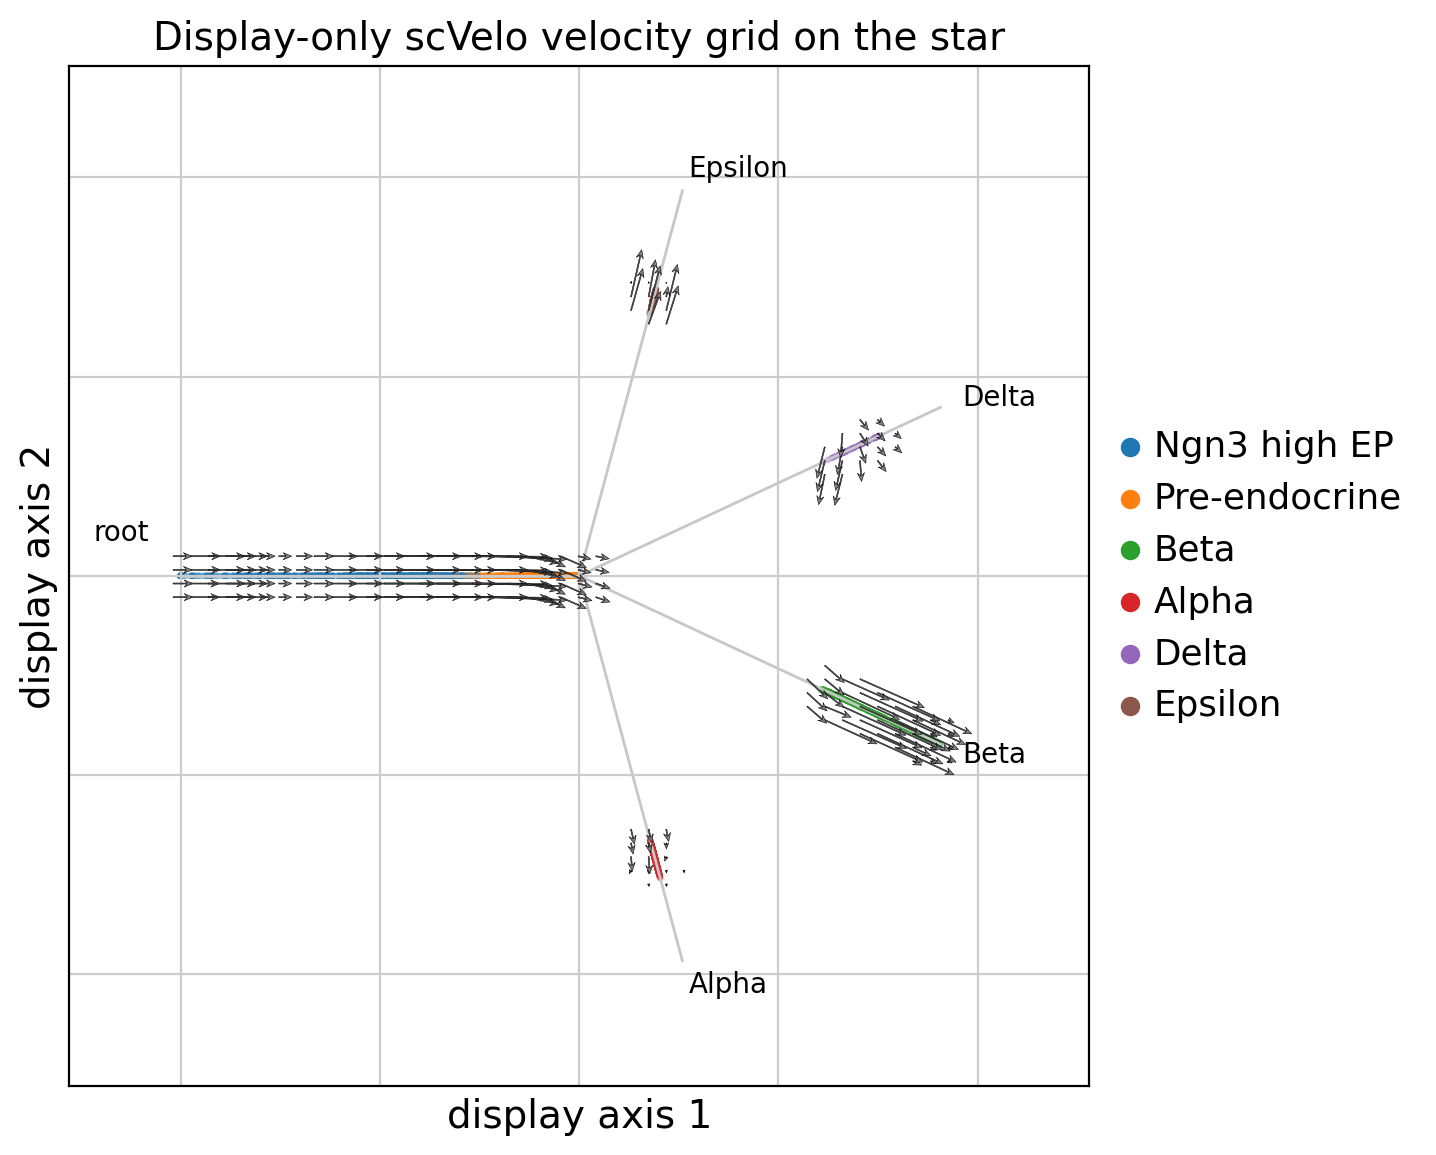

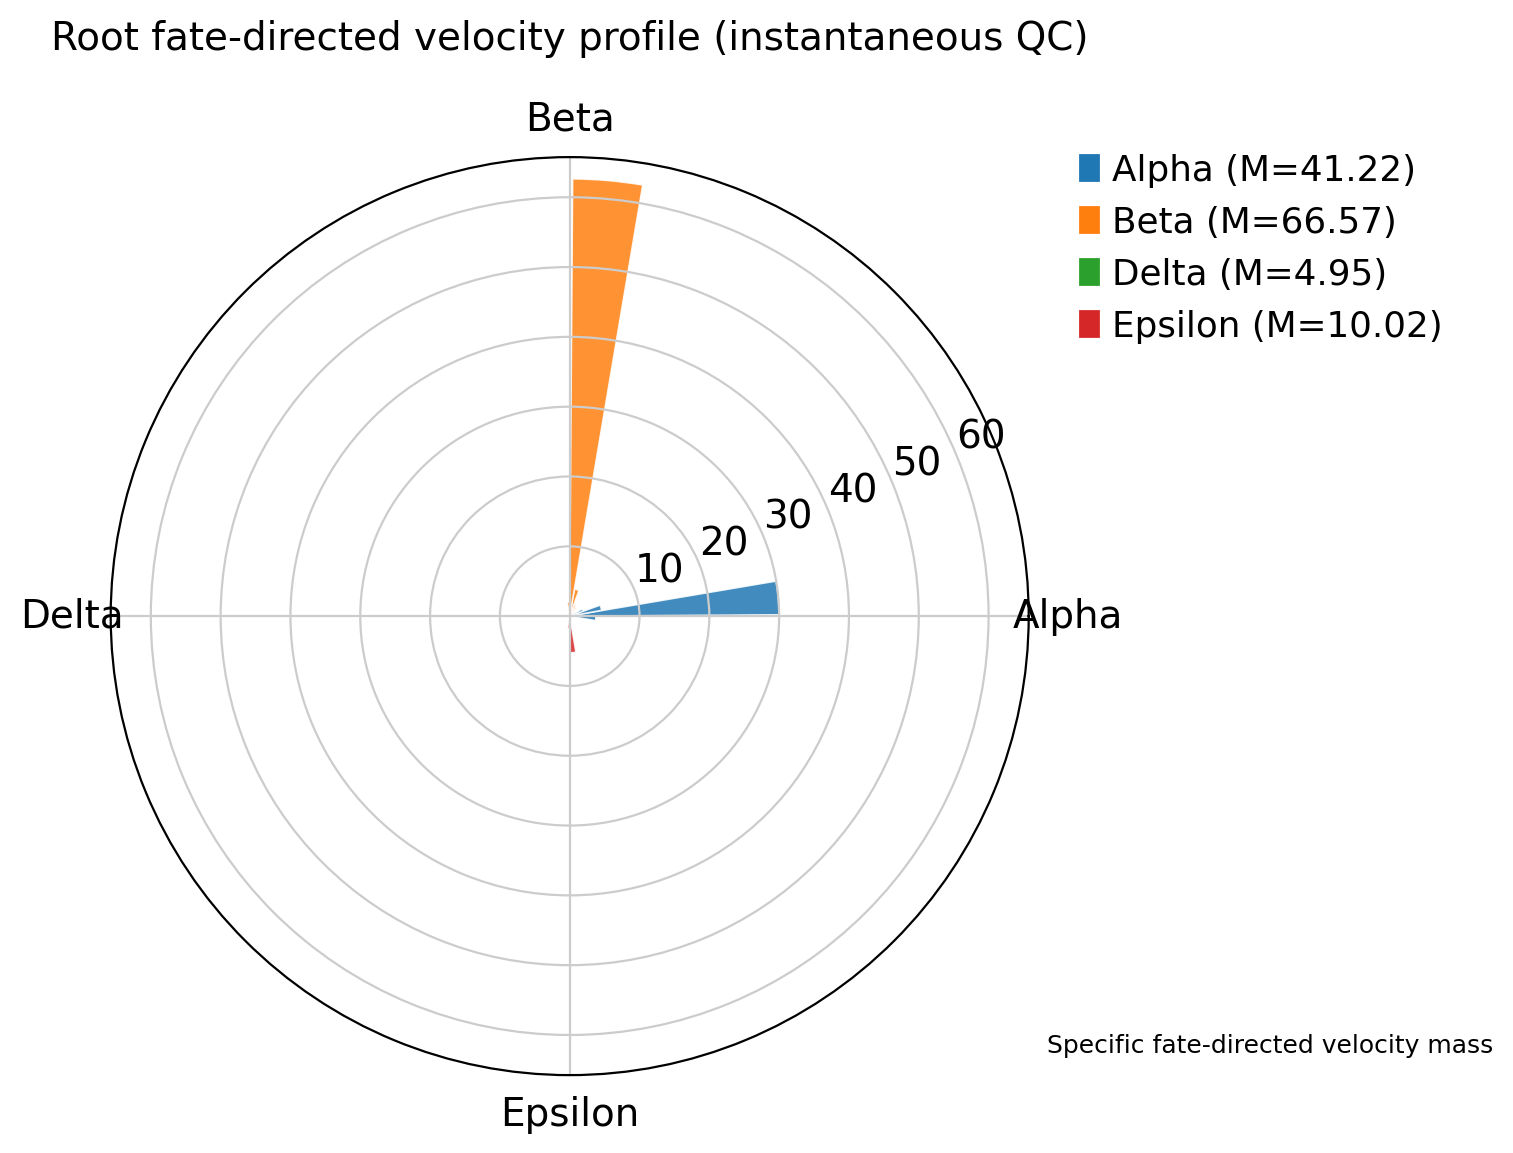

computing velocity embedding
    finished (0:00:00)


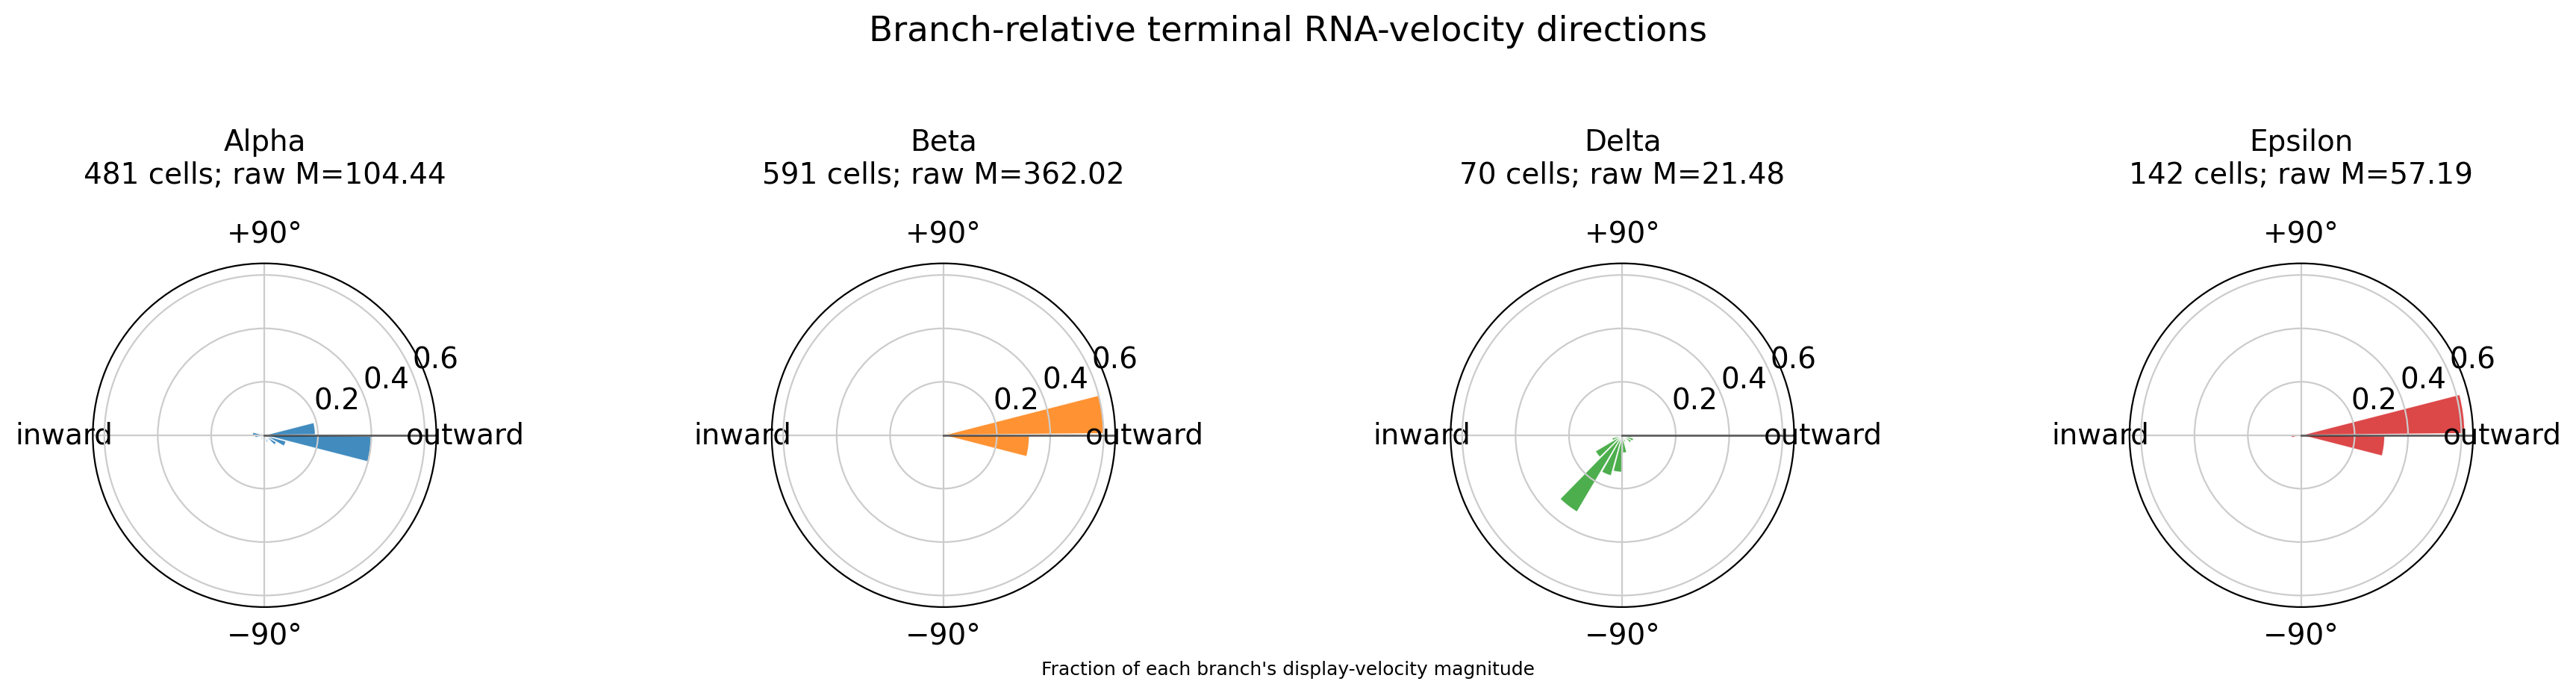

In [12]:
# First summarize the scientific future-fate result. This table and the root
# future-fate composition plot answer which fate is dominant. Display-space
# arrows answer a different question and can be curved or retrograde.
terminal_labels = np.asarray(result.embedding.selected_labels).astype(str)
terminal_qc_rows = []
for fate_index, fate in enumerate(FATES):
    fate_mask = result.terminal_mask & (terminal_labels == fate)
    terminal_qc_rows.append(
        {
            "fate": fate,
            "n_cells": int(fate_mask.sum()),
            "mean_own_future_fate_affinity": float(
                np.nanmean(result.future_fate_affinity[fate_mask, fate_index])
            ),
            "mean_future_fate_reach": float(np.nanmean(result.future_fate_reach[fate_mask])),
            "mean_signed_progression": float(np.nanmean(result.signed_progression[fate_mask])),
        }
    )
display(pd.DataFrame(terminal_qc_rows).set_index("fate"))

# Build a separate instantaneous scorer only for RNA-velocity display QC.
# This does not alter the primary discounted future-fate result.
instantaneous_display_scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="clusters",
)
instantaneous_display_scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
    verbose=False,
)
instantaneous_display_scorer.fit(scoring_mode="instantaneous", verbose=False)
instantaneous_display_result = instantaneous_display_scorer.score(
    write_to_adata=False,
    verbose=False,
)

# Native scVelo projection onto the straightened star. Curved, loop-like, or
# retrograde source trajectories can therefore look inward on some branches.
fig, ax = plt.subplots(figsize=(8, 6))
instantaneous_display_scorer.plot_velocity_embedding_grid(
    instantaneous_display_result,
    population="all",
    density=0.9,
    smooth=0.55,
    min_mass=1.0,
    n_neighbors=50,
    projection_mode="scvelo",
    title="Display-only scVelo velocity grid on the star",
    ax=ax,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "display_velocity_grid.png", dpi=200, bbox_inches="tight")
plt.show()

# Root fate-directed velocity after removing incoming-root progression. This
# is the closest analogue of the familiar binned commitment rose and does not
# assign the incoming root direction to a terminal sector.
root_rose = plt.figure(figsize=(8.5, 6.5))
root_rose_ax = root_rose.add_subplot(111, projection="polar")
instantaneous_display_scorer.plot_rose(
    instantaneous_display_result,
    population="root",
    mode="branch",
    n_bins=36,
    normalization="mass",
    title="Root fate-directed velocity profile (instantaneous QC)",
    ax=root_rose_ax,
)
root_rose.subplots_adjust(right=0.72)
root_rose.savefig(OUTPUT_DIR / "root_branch_velocity_rose.png", dpi=200, bbox_inches="tight")
plt.show()

# Terminal branches are shown separately. Each panel keeps cells attached to
# their annotated branch: 0° is outward, ±90° is transverse, and 180° is
# inward. Thus a retrograde Delta, Epsilon, or Gut vector is never relabeled as
# movement toward a different fate merely because of the 2D star layout.
branch_profiles = instantaneous_display_scorer.plot_branch_velocity_profiles(
    instantaneous_display_result,
    n_bins=24,
    normalization="within_branch",
    projection_mode="scvelo",
    title="Branch-relative terminal RNA-velocity directions",
)
branch_profiles.savefig(
    OUTPUT_DIR / "branch_relative_velocity_profiles.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 12. Gene expression on the star


Resolved markers: ['Neurog3', 'Gcg', 'Ins1', 'Ins2', 'Sst', 'Ghrl']
Missing markers: []


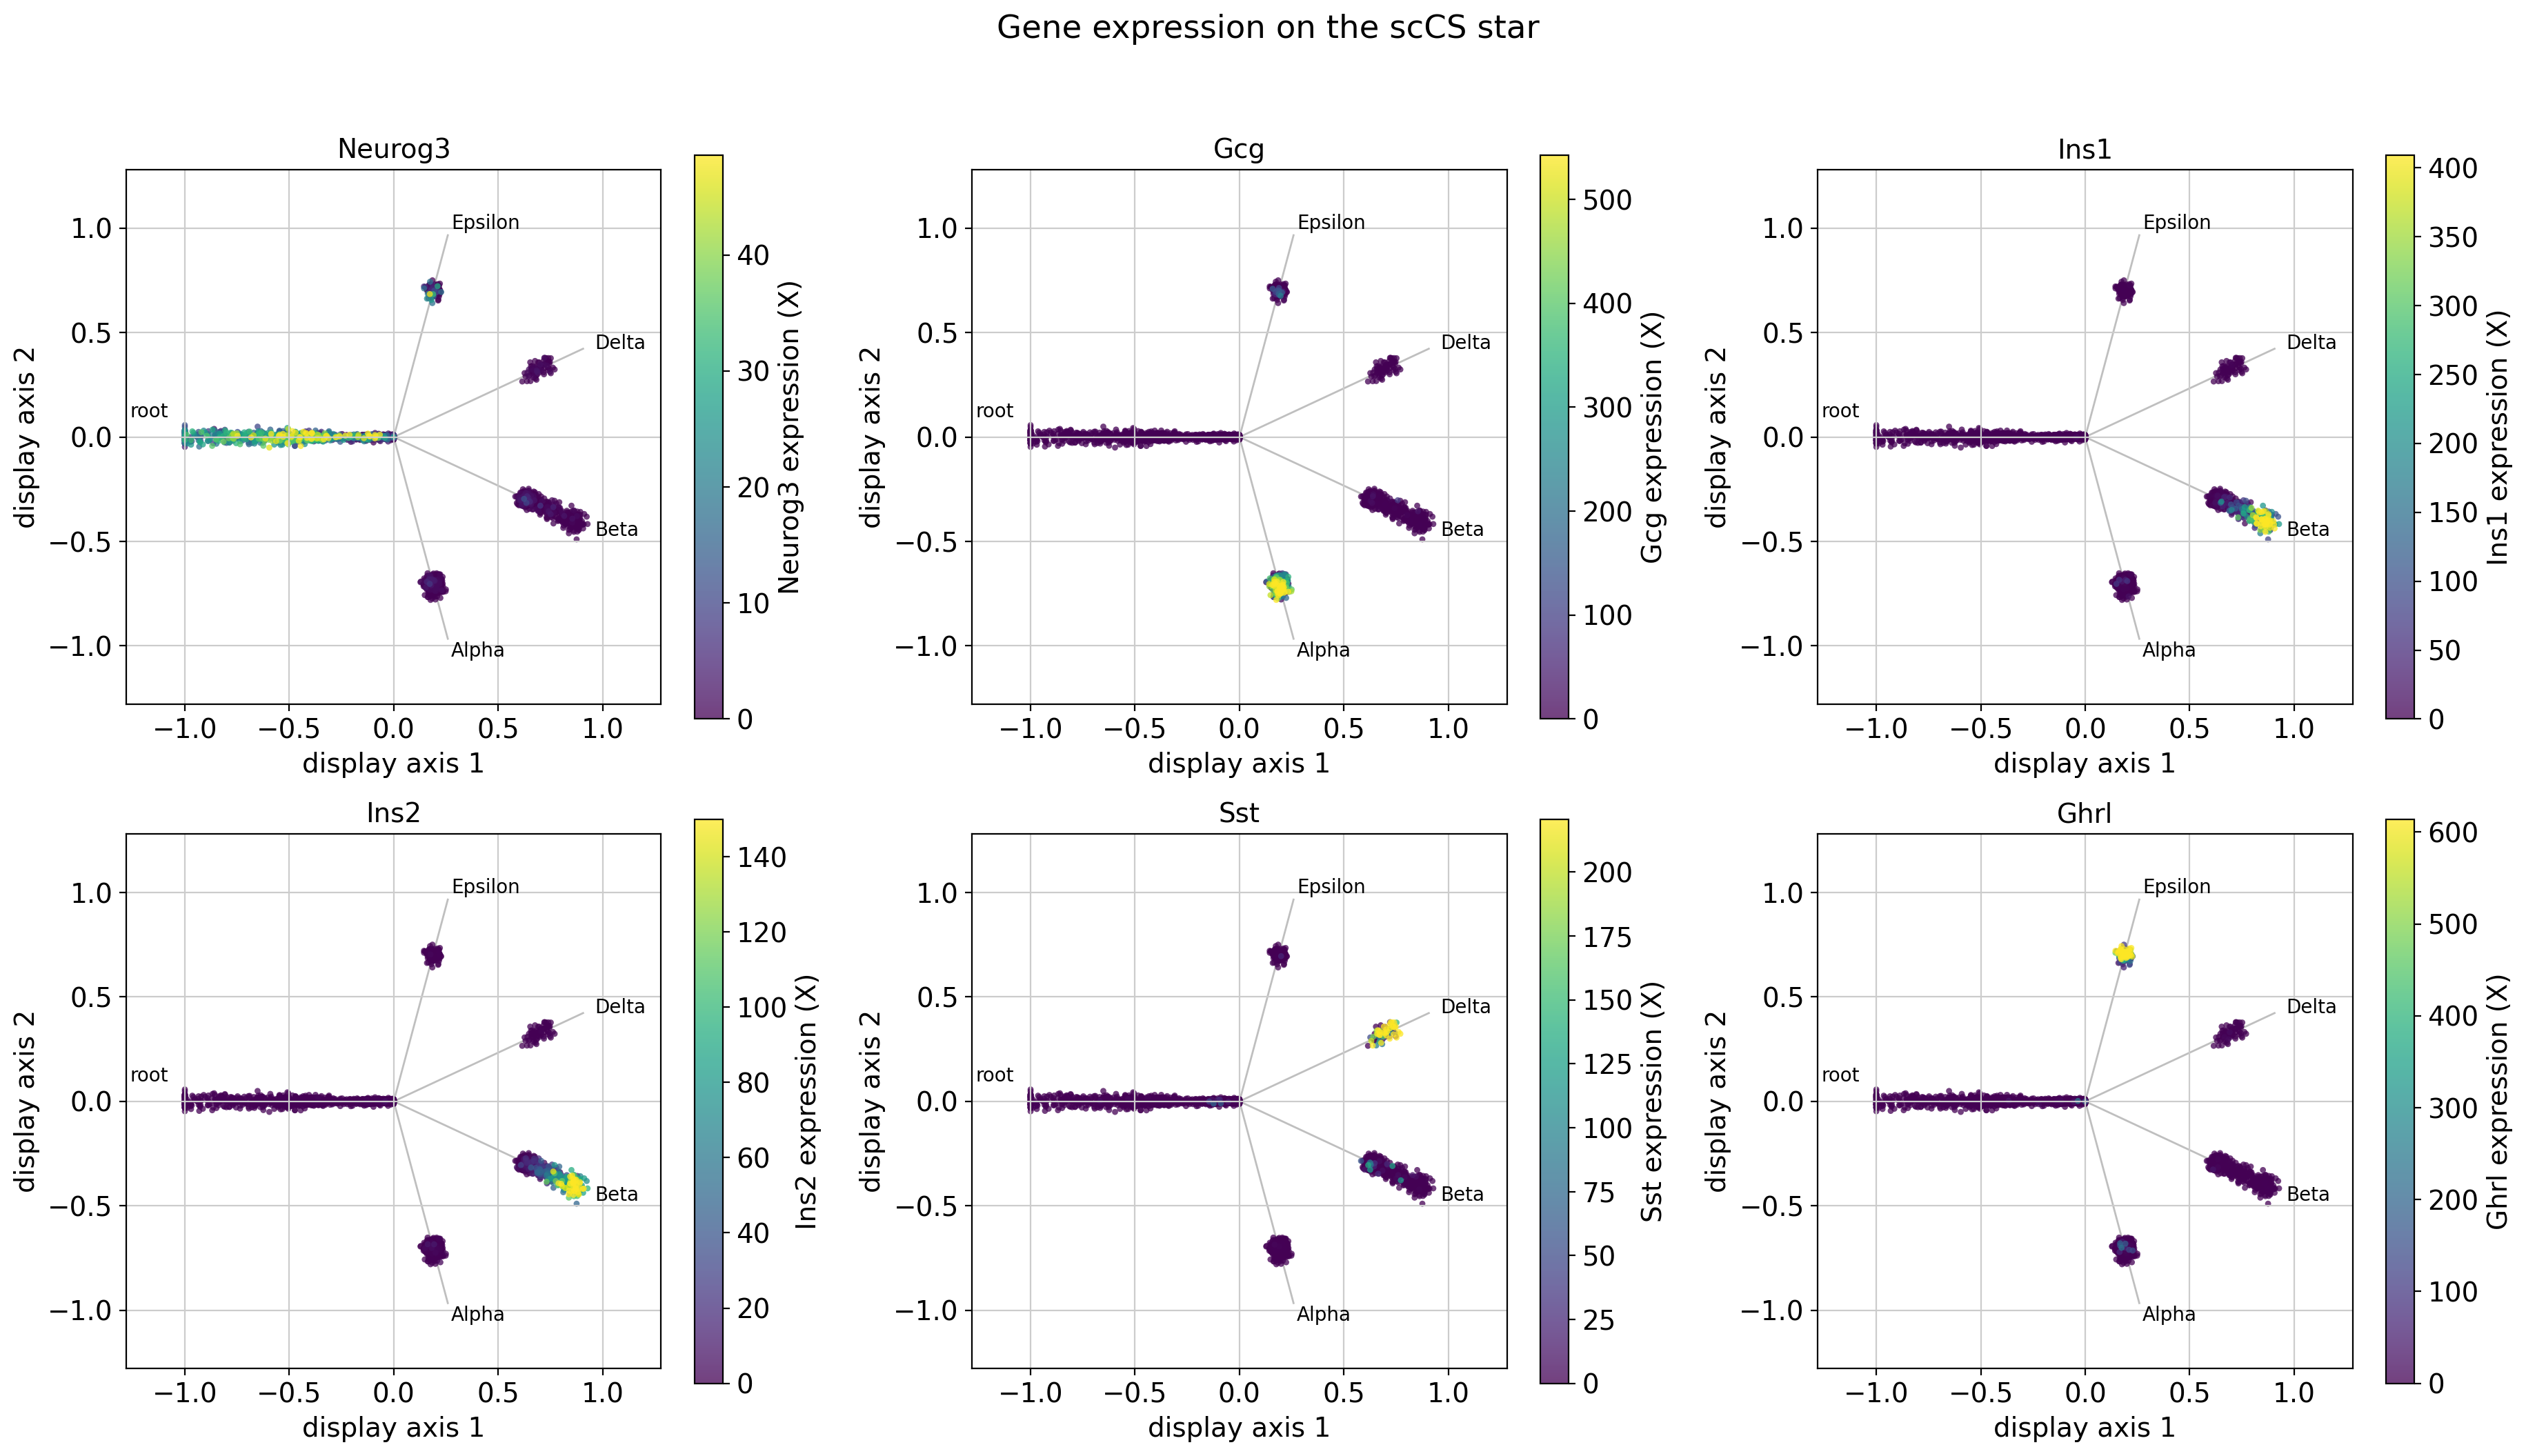

In [13]:
marker_candidates = ["Neurog3", "Gcg", "Ins1", "Ins2", "Sst", "Ghrl"]
markers, missing_markers = resolve_present_genes(adata, marker_candidates)
print("Resolved markers:", markers)
print("Missing markers:", missing_markers)
if markers:
    marker_fig = scorer.plot_gene_expression_star(
        markers,
        result,
        terminal_layout="ordering",
        ncols=3,
        shared_scale=False,
    )
    marker_fig.savefig(OUTPUT_DIR / "marker_expression_stars.png", dpi=200, bbox_inches="tight")
    plt.show()

## 13. Expression trends along the supplied ordering


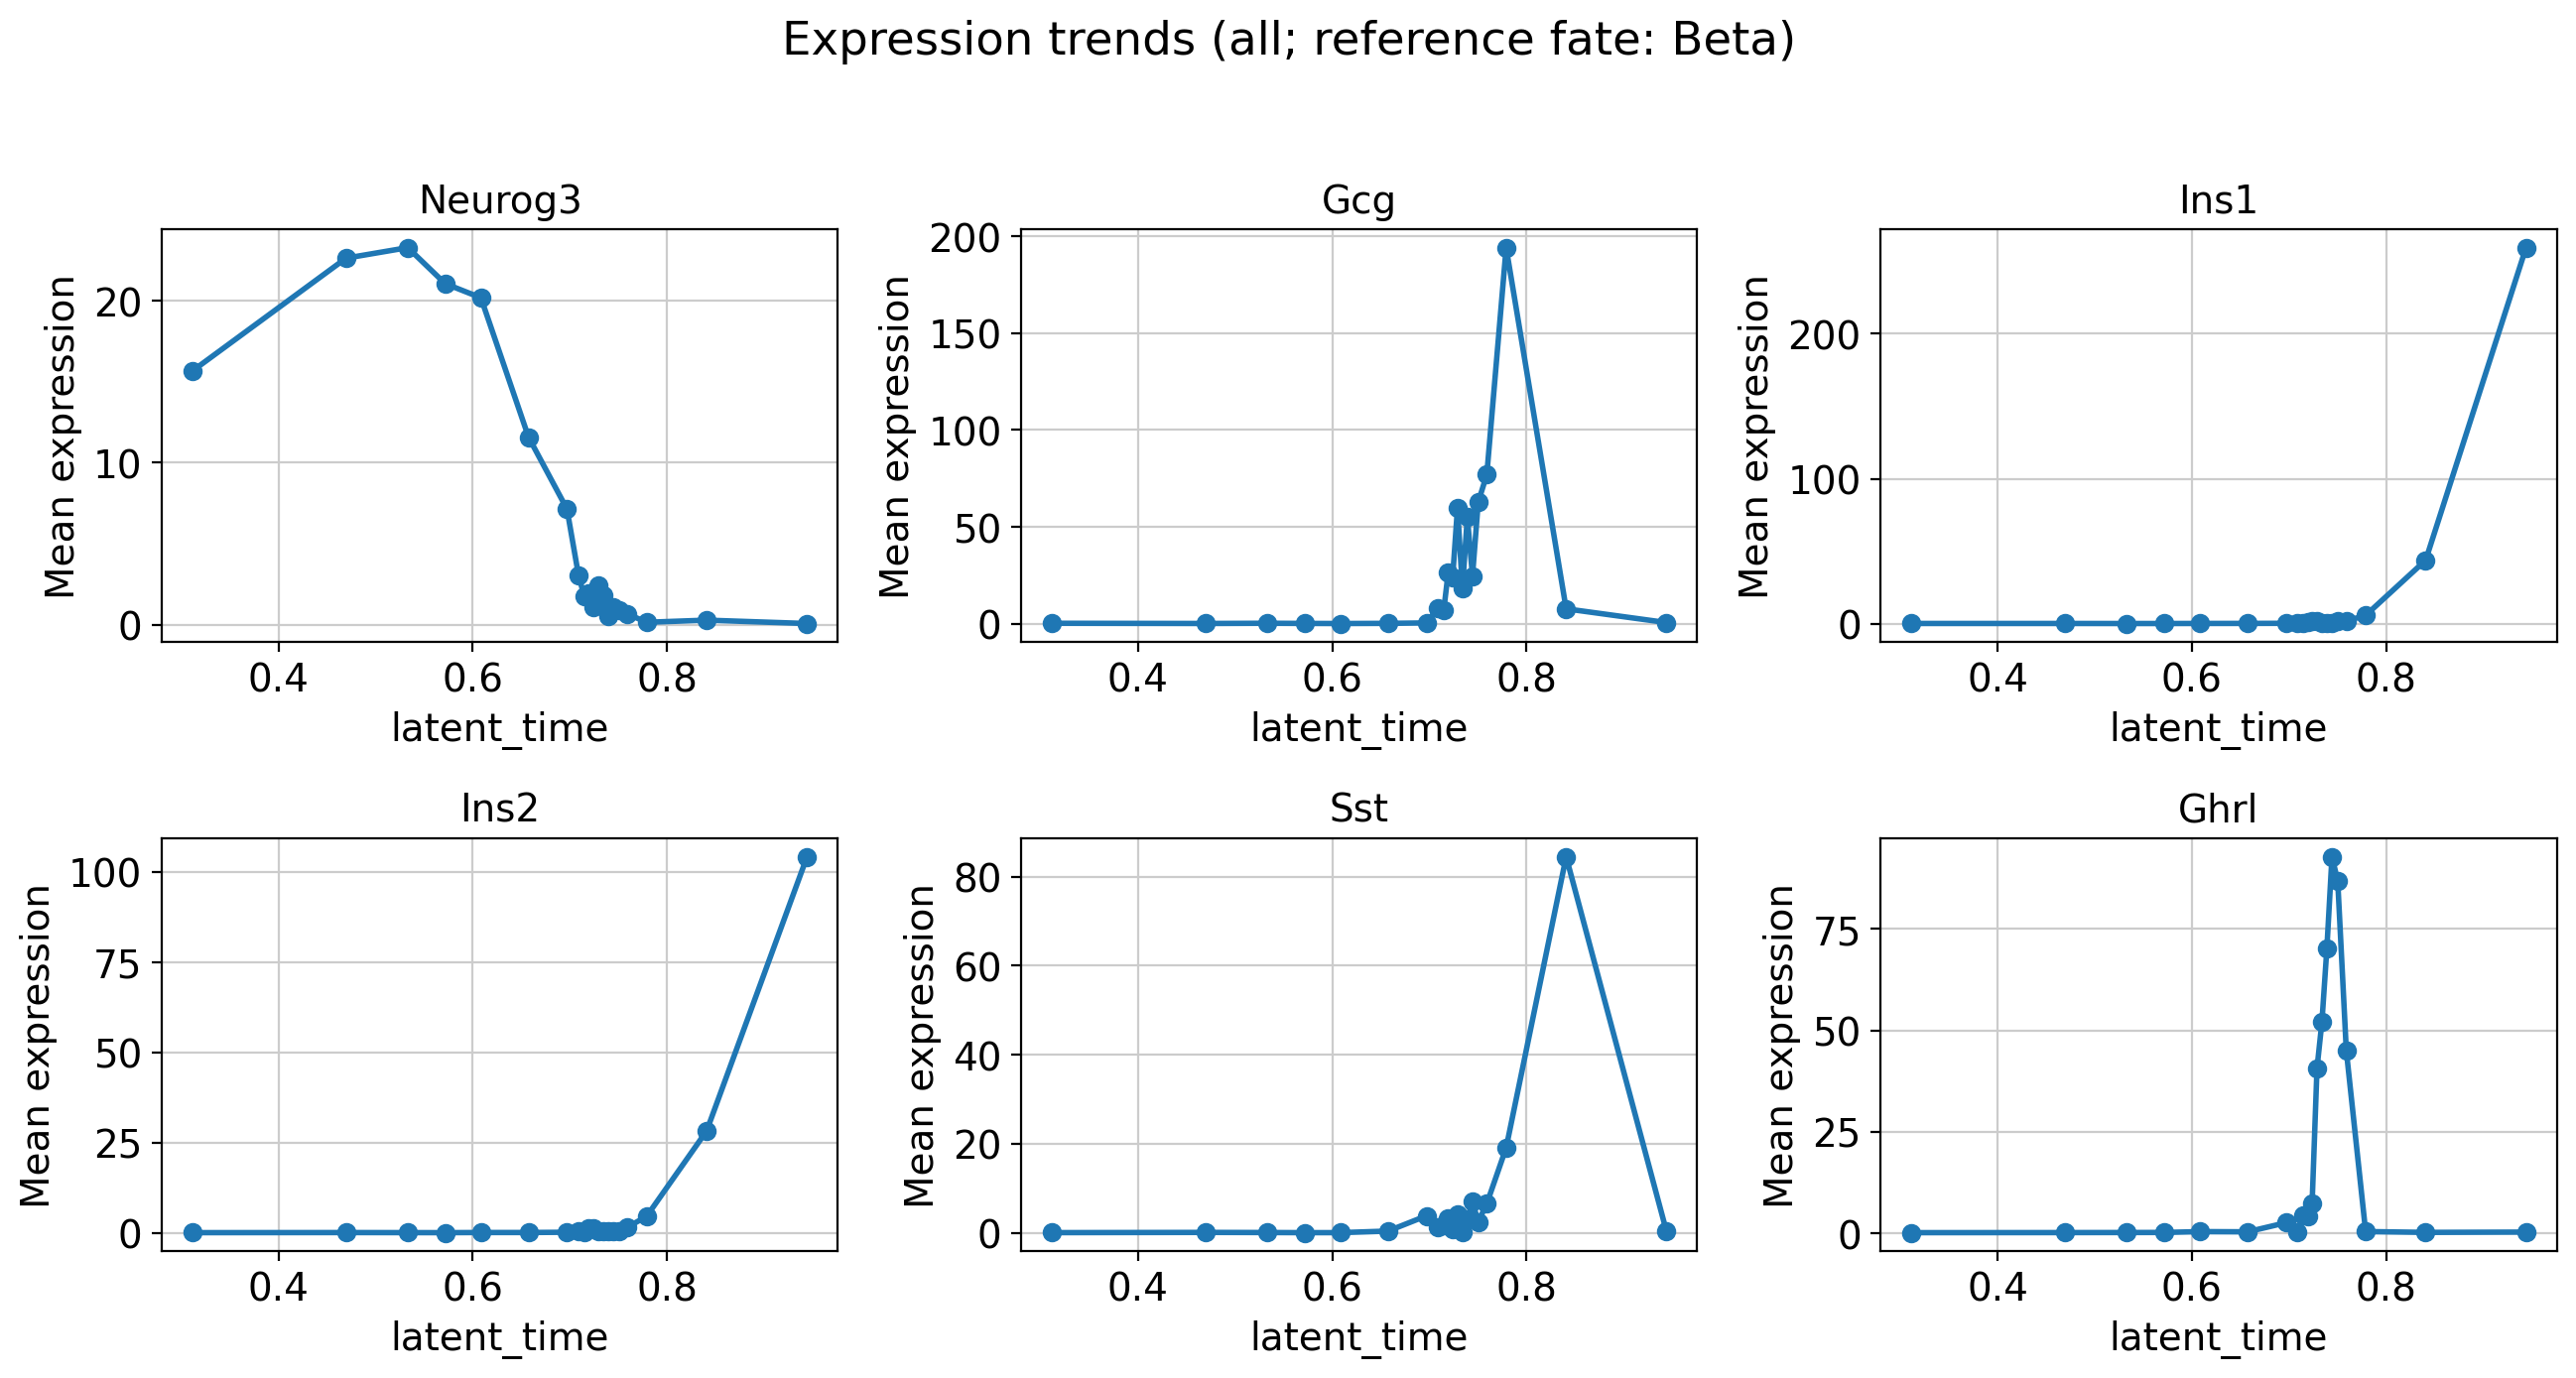

In [14]:
if markers:
    trend_fig = scorer.plot_expression_trends(
        markers,
        result,
        x_axis="ordering",
        population="all",
        n_bins=20,
        ncols=3,
    )
    trend_fig.savefig(OUTPUT_DIR / "marker_expression_trends.png", dpi=200, bbox_inches="tight")
    plt.show()

## 14. Candidate genes associated with future-fate outputs

Cell-level associations are exploratory because cells are not independent
biological replicates. Use `inference_unit="replicate"` only when a valid
independent replicate column exists and enough units pass the minimum-cell filter.
Associations are candidates, not causal lineage drivers.


In [15]:
association = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="cell_exploratory",
    pseudotime_key=ORDERING_KEY,
    min_cells=100,
    min_feature_cells=10,
    min_feature_fraction=0.01,
    n_top_genes=30,
    verbose=True,
)
for fate in FATES:
    print("\n", fate)
    display(association.top(fate, n=15))
association.export(OUTPUT_DIR, prefix="future_fate_gene_association")


[scCS] Candidate commitment-associated genes: Alpha
        inference_unit=cell_exploratory; matrix=X; n_units=1234; tested_genes=6946
 rank    gene   effect   pvalue_adj  significant
    1  Tmsb4x 0.275744 6.866232e-20         True
    2 Neurog3 0.249886 5.188467e-16         True
    3    Ppib 0.242993 3.842847e-15         True
    4     Mdk 0.242233 4.414893e-15         True
    5    Rps9 0.239684 9.050625e-15         True
    6     Cck 0.234886 2.988312e-14         True
    7    Btg2 0.233772 3.955025e-14         True
    8  Btbd17 0.233522 4.020746e-14         True
    9    Cd63 0.229856 1.163901e-13         True
   10 Igfbpl1 0.225002 4.719493e-13         True
   11   Rps11 0.220966 1.330870e-12         True
   12 Gadd45a 0.218992 2.158346e-12         True
   13    Pax4 0.214899 6.643259e-12         True
   14    Cdk4 0.208052 3.532527e-11         True
   15    Dbn1 0.203733 1.012706e-10         True
   16 Smarcd2 0.202143 1.460725e-10         True
   17    Selm 0.200973 1.935800

,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Tmsb4x,0.275744,5.931096e-23,6.866232e-20,26.480909,25.720442,1169,1234,True,0.275744,1
1,Neurog3,0.249886,5.228804e-19,5.188467e-16,13.379286,13.727636,988,1234,True,0.249886,2
2,Ppib,0.242993,4.979215e-18,3.842847e-15,8.263345,5.597094,1201,1234,True,0.242993,3
3,Mdk,0.242233,6.356023e-18,4.414893e-15,15.501658,12.948563,1124,1234,True,0.242233,4
4,Rps9,0.239684,1.433298e-17,9.050625e-15,32.504977,9.654044,1234,1234,True,0.239684,5
5,Cck,0.234886,6.453309e-17,2.988312e-14,20.157887,22.982749,994,1234,True,0.234886,6
6,Btg2,0.233772,9.110337e-17,3.955025e-14,8.378012,5.691946,1196,1234,True,0.233772,7
7,Btbd17,0.233522,9.840581e-17,4.020746e-14,5.285445,5.445983,882,1234,True,0.233522,8
8,Cd63,0.229856,3.016156e-16,1.163901e-13,10.626693,5.767550,1221,1234,True,0.229856,9
9,Igfbpl1,0.225002,1.290964e-15,4.719493e-13,2.379176,3.276287,703,1234,True,0.225002,10



 Beta


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Pcsk2,0.240656,1.052197e-17,3.654280e-14,0.824410,2.119913,285,1234,True,0.240656,1
1,Rbp4,0.224756,1.388129e-15,3.213982e-12,6.374880,17.573840,573,1234,True,0.224756,2
2,Npepl1,0.218365,8.927872e-15,1.550325e-11,1.879040,2.161760,844,1234,True,0.218365,3
3,Pdx1,0.216645,1.458831e-14,2.026609e-11,1.220922,1.919877,586,1234,True,0.216645,4
4,Mnx1,0.215440,2.052819e-14,2.376480e-11,0.251422,0.889925,125,1234,True,0.215440,5
5,Pim2,0.195233,4.674078e-12,4.638021e-09,0.999573,1.959778,460,1234,True,0.195233,6
6,1700086L19Rik,0.187750,3.028669e-11,2.629641e-08,1.625739,3.346094,461,1234,True,0.187750,7
7,Pyy,0.183906,7.680592e-11,5.927710e-08,15.748496,61.305059,631,1234,True,0.183906,8
8,Fxyd6,0.180545,1.705015e-10,1.184303e-07,0.975067,1.746535,455,1234,True,0.180545,9
9,Chgb,0.178527,2.732536e-10,1.725473e-07,26.170255,48.147127,615,1234,True,0.178527,10



 Delta


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Cdkn1a,0.341412,4.921791e-35,3.418676e-31,7.192985,11.485302,930,1234,True,0.341412,1
1,Mboat4,0.338549,1.923454e-34,6.680157e-31,0.244339,1.053657,119,1234,True,0.338549,2
2,Isl1,0.297690,1.187606e-26,2.019228e-23,3.723734,8.049448,438,1234,True,0.297690,3
3,Arx,0.297191,1.453519e-26,2.019228e-23,0.548678,1.612283,209,1234,True,0.297191,4
4,Cd200,0.287990,5.620897e-25,6.507125e-22,0.846095,1.491867,425,1234,True,0.287990,5
5,Peg3,0.269294,6.283696e-22,6.235222e-19,5.624904,5.022496,1143,1234,True,0.269294,6
6,Tm4sf4,0.249135,6.707171e-19,5.823501e-16,3.366878,4.171071,862,1234,True,0.249135,7
7,Peg10,0.233154,1.102107e-16,6.379363e-14,0.182685,0.908079,72,1234,True,0.233154,8
8,Trp53cor1,0.228891,4.037835e-16,2.157446e-13,0.106156,0.414571,95,1234,True,0.228891,9
9,Glud1,0.214502,2.674047e-14,1.092584e-11,3.630171,4.123165,972,1234,True,0.214502,10



 Epsilon


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Cdkn1a,0.309303,9.612805e-29,6.677054e-25,7.192985,11.485302,930,1234,True,0.309303,1
1,Arx,0.303512,1.090822e-27,3.788425e-24,0.548678,1.612283,209,1234,True,0.303512,2
2,Mboat4,0.290981,1.738531e-25,4.025278e-22,0.244339,1.053657,119,1234,True,0.290981,3
3,Tm4sf4,0.237835,2.569547e-17,2.868121e-14,3.366878,4.171071,862,1234,True,0.237835,4
4,Peg3,0.237758,2.632457e-17,2.868121e-14,5.624904,5.022496,1143,1234,True,0.237758,5
5,Glud1,0.237460,2.890418e-17,2.868121e-14,3.630171,4.123165,972,1234,True,0.237460,6
6,Cd200,0.229925,2.953960e-16,1.865291e-13,0.846095,1.491867,425,1234,True,0.229925,7
7,Trp53cor1,0.211789,5.707460e-14,2.642934e-11,0.106156,0.414571,95,1234,True,0.211789,8
8,Muc1,0.208200,1.531472e-13,6.648502e-11,0.439841,0.891349,326,1234,True,0.208200,9
9,Anpep,0.187485,3.231839e-11,1.181492e-08,0.294801,0.849643,224,1234,True,0.187485,10


['tutorial_outputs/pancreas_single/future_fate_gene_association_Alpha.csv',
 'tutorial_outputs/pancreas_single/future_fate_gene_association_Beta.csv',
 'tutorial_outputs/pancreas_single/future_fate_gene_association_Delta.csv',
 'tutorial_outputs/pancreas_single/future_fate_gene_association_Epsilon.csv',
 'tutorial_outputs/pancreas_single/future_fate_gene_association_metadata.json']

## 15. Terminal annotation markers


In [16]:
fate_markers = scorer.get_fate_markers(
    n_genes=50,
    fdr_threshold=0.05,
    logfc_threshold=0.25,
    min_cells=10,
    verbose=True,
)
for fate, table in fate_markers.items():
    print("\n", fate)
    display(table.head(15))
    table.to_csv(OUTPUT_DIR / f"terminal_markers_{fate}.csv", index=False)

ranking genes
    finished (0:00:00)

[scCS] Fate markers: Alpha vs root; significant=50
 rank    gene  logfoldchange    pvalue_adj
    1     Pyy     233.343811 1.051944e-160
    2     Gcg     209.721115  1.613987e-83
    3    Iapp     100.156334 3.267432e-138
    4     Ttr      69.962547 3.499607e-146
    5    Gnas      51.120472 2.153794e-130
    6    Rbp4      43.370220 7.934233e-127
    7  Tmem27      18.768389 3.627194e-200
    8 Slc38a5      18.712347 1.562776e-124
    9  Pcsk1n      17.453619 6.113637e-142
   10     Cpe      13.869763 1.434444e-125
   11 Slc25a5      12.463739  3.970180e-52
   12    Gast      11.470784  3.008741e-52
   13   Pcsk2       9.351954 1.479988e-117
   14    Gpx3       8.338355 3.580264e-131
   15   Meis2       8.270338 1.147131e-145
   16   Peg10       7.708434  2.012753e-97
   17    Isl1       7.264405  2.414985e-71
   18    Ssr2       6.711359 2.825360e-103
   19 Tmsb15l       6.403490 1.952847e-101
   20  Tspan7       6.041723 1.076545e-122
ranking 

,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Pyy,27.298784,233.343811,4.384929e-164,1.051944e-160,0.968815,True,terminal_annotation_marker_vs_root,1
1,Gcg,19.606232,209.721115,1.367976e-85,1.613987e-83,0.656965,True,terminal_annotation_marker_vs_root,2
2,Iapp,25.275759,100.156334,5.901990e-141,3.267432e-138,0.854470,True,terminal_annotation_marker_vs_root,3
3,Ttr,26.014395,69.962547,3.403814e-149,3.499607e-146,1.000000,True,terminal_annotation_marker_vs_root,4
4,Gnas,24.545862,51.120472,4.788205e-133,2.153794e-130,1.000000,True,terminal_annotation_marker_vs_root,5
5,Rbp4,24.200369,43.370220,2.204872e-129,7.934233e-127,0.962578,True,terminal_annotation_marker_vs_root,6
6,Tmem27,30.478390,18.768389,5.039869e-204,3.627194e-200,0.981289,True,terminal_annotation_marker_vs_root,7
7,Slc38a5,23.975632,18.712347,4.994283e-127,1.562776e-124,0.920998,True,terminal_annotation_marker_vs_root,8
8,Pcsk1n,25.622826,17.453619,8.494702e-145,6.113637e-142,0.997921,True,terminal_annotation_marker_vs_root,9
9,Cpe,24.078638,13.869763,4.185540e-128,1.434444e-125,1.000000,True,terminal_annotation_marker_vs_root,10



 Beta


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Iapp,31.406631,186.131287,1.642611e-216,1.182187e-212,0.944162,True,terminal_annotation_marker_vs_root,1
1,Pyy,27.752472,162.698456,1.626816e-169,1.170819e-166,0.962775,True,terminal_annotation_marker_vs_root,2
2,Rbp4,30.064129,50.622169,1.427144e-198,2.567789e-195,0.996616,True,terminal_annotation_marker_vs_root,3
3,Ins2,20.527544,48.017612,1.221961e-93,9.881409e-92,0.610829,True,terminal_annotation_marker_vs_root,4
4,Gnas,27.004543,42.680595,1.307045e-160,7.839004e-158,1.000000,True,terminal_annotation_marker_vs_root,5
5,Nnat,25.606888,42.575066,1.278533e-144,3.539079e-142,0.825719,True,terminal_annotation_marker_vs_root,6
6,Ttr,19.382299,25.199047,1.088711e-83,7.322854e-82,0.994924,True,terminal_annotation_marker_vs_root,7
7,Sec61b,29.525990,13.772089,1.335784e-191,1.602273e-188,1.000000,True,terminal_annotation_marker_vs_root,8
8,Dlk1,25.691658,13.032376,1.448783e-145,4.344538e-143,0.966159,True,terminal_annotation_marker_vs_root,9
9,Pcsk1n,24.757769,11.741943,2.557147e-135,4.973997e-133,0.994924,True,terminal_annotation_marker_vs_root,10



 Delta


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Pyy,13.587565,507.735718,4.746092e-42,1.707881e-38,1.000000,True,terminal_annotation_marker_vs_root,1
1,Sst,12.178400,333.075989,4.051542e-34,3.239883e-31,0.871429,True,terminal_annotation_marker_vs_root,2
2,Rbp4,13.927866,204.135147,4.289831e-44,3.087391e-40,1.000000,True,terminal_annotation_marker_vs_root,3
3,Iapp,13.506161,103.372108,1.438297e-41,3.450474e-38,0.985714,True,terminal_annotation_marker_vs_root,4
4,Hhex,13.157539,18.528818,1.540203e-39,2.771210e-36,0.985714,True,terminal_annotation_marker_vs_root,5
5,Dlk1,12.181336,17.492176,3.908267e-34,3.239883e-31,1.000000,True,terminal_annotation_marker_vs_root,6
6,Cd24a,11.691277,17.178232,1.412473e-31,9.241425e-29,1.000000,True,terminal_annotation_marker_vs_root,7
7,Gnas,6.687908,16.492489,2.263842e-11,1.108358e-09,1.000000,True,terminal_annotation_marker_vs_root,8
8,Isl1,10.758631,14.357853,5.396626e-27,2.157751e-24,1.000000,True,terminal_annotation_marker_vs_root,9
9,Gpx3,12.019669,10.721635,2.800925e-33,2.015825e-30,0.985714,True,terminal_annotation_marker_vs_root,10



 Epsilon


,gene,score,logfoldchange,pvalue,pvalue_adj,pct_terminal,significant,analysis_type,rank
0,Ghrl,19.460413,496.845154,2.378630e-84,1.711900e-80,1.000000,True,terminal_annotation_marker_vs_root,1
1,Pyy,12.460391,105.076279,1.227675e-35,1.520765e-33,0.873239,True,terminal_annotation_marker_vs_root,2
2,Rbp4,17.321424,84.230026,3.242339e-67,1.166756e-63,0.992958,True,terminal_annotation_marker_vs_root,3
3,Lrpprc,12.808173,26.874617,1.475683e-37,2.212602e-35,0.873239,True,terminal_annotation_marker_vs_root,4
4,Isl1,16.356800,23.863163,3.890428e-60,5.599882e-57,0.992958,True,terminal_annotation_marker_vs_root,5
5,Iapp,12.045594,19.742641,2.045959e-33,2.165407e-31,0.760563,True,terminal_annotation_marker_vs_root,6
6,Maged2,15.854918,16.161346,1.299961e-56,1.336546e-53,0.943662,True,terminal_annotation_marker_vs_root,7
7,Bsg,15.654099,13.106299,3.114929e-55,2.802268e-52,1.000000,True,terminal_annotation_marker_vs_root,8
8,Slc38a5,11.426969,10.352853,3.066283e-30,2.793423e-28,0.838028,True,terminal_annotation_marker_vs_root,9
9,Tmem27,12.752644,10.297958,3.013492e-37,4.252569e-35,0.739437,True,terminal_annotation_marker_vs_root,10


## 16. Optional local enrichment

For a reproducible analysis, provide a local GMT file or an explicit mapping of
pathway names to genes. The tested genes—not the complete genome—form the default
enrichment background.


In [17]:
GMT_PATH = Path("gene_sets.gmt")
if GMT_PATH.exists():
    gene_sets = scCS.load_gmt(GMT_PATH)
    enrichment = scCS.run_commitment_enrichment(
        association,
        gene_sets=gene_sets,
        direction="positive",
        significant_only=False,
        max_genes=300,
        min_query_genes=5,
        min_set_size=5,
        organism="mouse",
    )
    enrichment.export(OUTPUT_DIR, prefix="future_fate_enrichment")
    for fate in FATES:
        if fate in enrichment.tables and not enrichment.tables[fate].empty:
            fig, ax = plt.subplots(figsize=(8, 5))
            scCS.plot_enrichment_dotplot(enrichment, fate, n_terms=15, ax=ax)
            fig.tight_layout()
            fig.savefig(
                OUTPUT_DIR / f"enrichment_{fate}.png",
                dpi=200,
                bbox_inches="tight",
            )
            plt.show()
else:
    print("No gene_sets.gmt file found; enrichment section skipped.")

No gene_sets.gmt file found; enrichment section skipped.


## 17. Horizon and anchor sensitivity


In [18]:
sensitivity = {}
for horizon in (32, 64, 128):
    for quantile in (0.85, 0.90, 0.95):
        scorer.fit(
            scoring_mode="future_fate",
            future_fate_options={
                **FUTURE_OPTIONS,
                "effective_horizon": horizon,
                "anchor_quantile": quantile,
                "verbose": False,
            },
            verbose=False,
        )
        sensitivity[(horizon, quantile)] = scorer.score(
            write_to_adata=False,
            verbose=False,
        )

primary = sensitivity[(64, 0.90)]
root = primary.root_mask
h64_h128 = row_js(
    sensitivity[(64, 0.90)].future_fate_affinity[root],
    sensitivity[(128, 0.90)].future_fate_affinity[root],
)
q85_q95 = row_js(
    sensitivity[(64, 0.85)].future_fate_affinity[root],
    sensitivity[(64, 0.95)].future_fate_affinity[root],
)
sensitivity_table = pd.DataFrame(
    {
        "criterion": [
            "median root affinity JS: h64 vs h128",
            "median root affinity JS: q0.85 vs q0.95",
            "mean root reach: h32",
            "mean root reach: h64",
            "mean root reach: h128",
        ],
        "value": [
            np.nanmedian(h64_h128),
            np.nanmedian(q85_q95),
            sensitivity[(32, 0.90)].future_fate_reach[root].mean(),
            sensitivity[(64, 0.90)].future_fate_reach[root].mean(),
            sensitivity[(128, 0.90)].future_fate_reach[root].mean(),
        ],
    }
)
display(sensitivity_table)
sensitivity_table.to_csv(OUTPUT_DIR / "sensitivity_summary.csv", index=False)
result = primary

,criterion,value
0,median root affinity JS: h64 vs h128,0.000348
1,median root affinity JS: q0.85 vs q0.95,0.001157
2,mean root reach: h32,0.458132
3,mean root reach: h64,0.624050
4,mean root reach: h128,0.760471


## 18. Compare future-fate and instantaneous questions


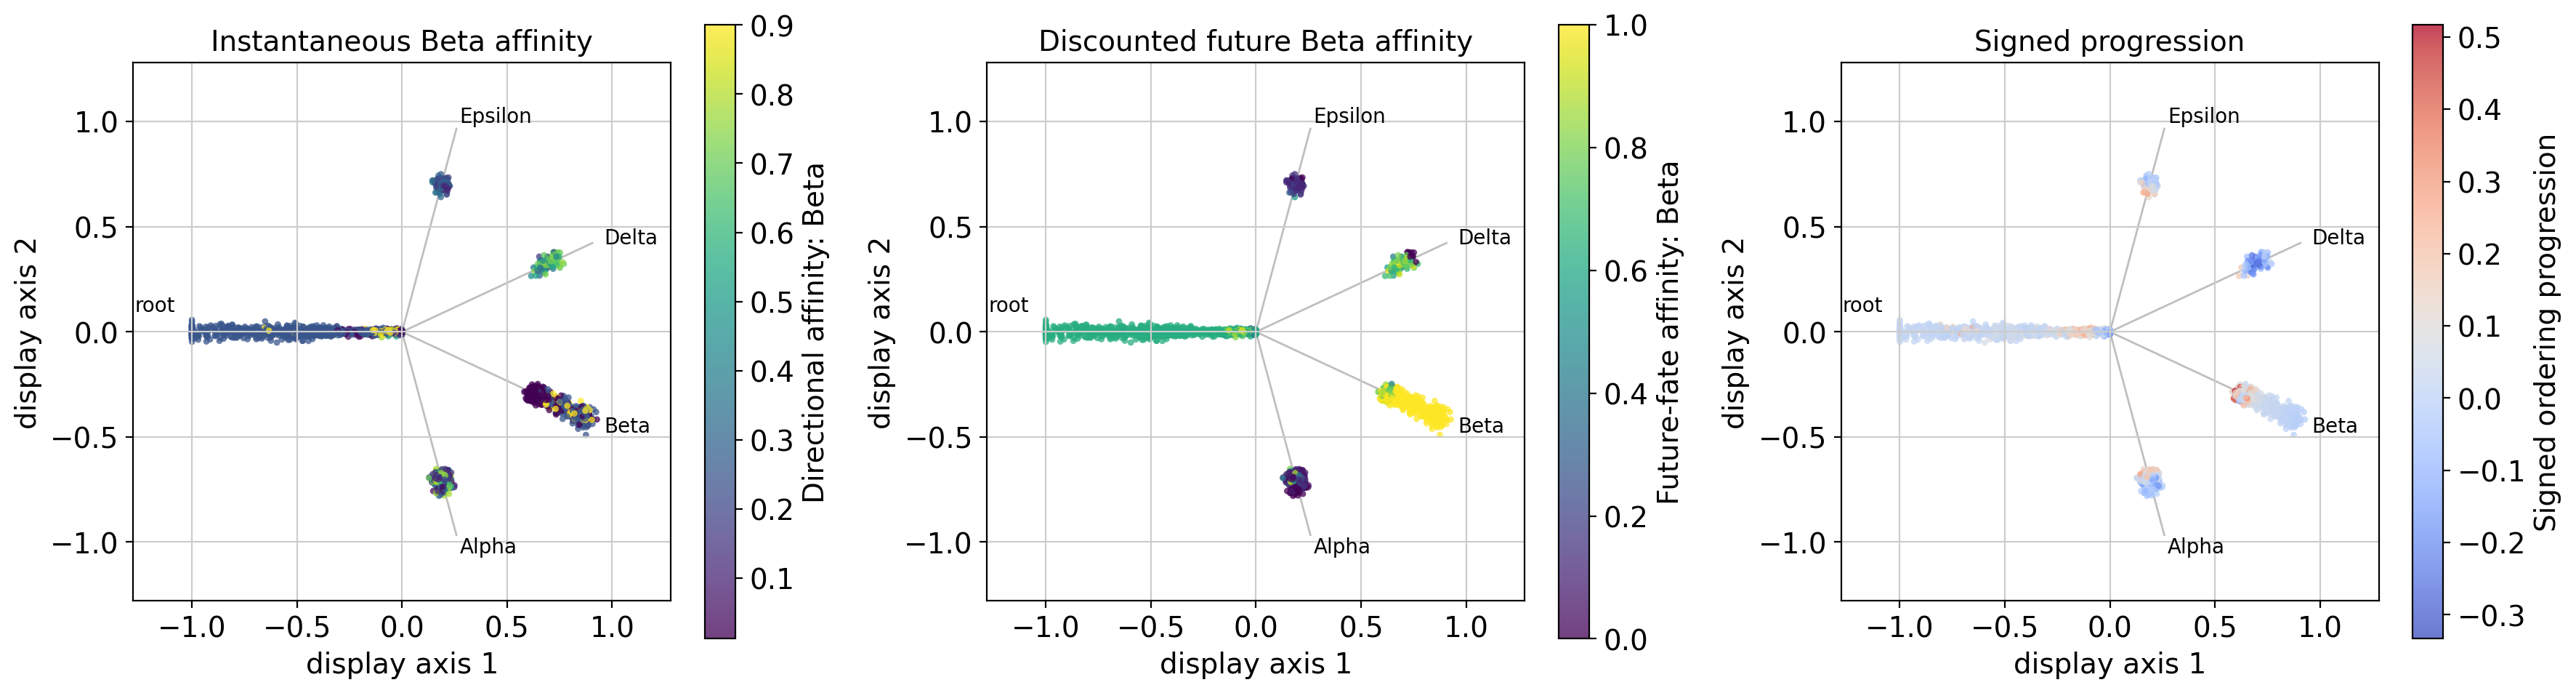

In [19]:
instantaneous = instantaneous_display_result
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
instantaneous_display_scorer.plot_star(
    instantaneous,
    color_by="affinity:Beta",
    title="Instantaneous Beta affinity",
    ax=axes[0],
)
scorer.plot_star(
    result,
    color_by="future_fate_affinity:Beta",
    title="Discounted future Beta affinity",
    ax=axes[1],
)
scorer.plot_star(
    result,
    color_by="signed_progression",
    title="Signed progression",
    cmap="coolwarm",
    ax=axes[2],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "instantaneous_vs_future_fate.png", dpi=200, bbox_inches="tight")
plt.show()

## 19. Export reproducible analysis objects


In [20]:
result.write_to_adata(adata)
adata.write_h5ad(OUTPUT_DIR / "pancreas_sccs_future_fate.h5ad")

cell_table = adata.obs.loc[result.cell_ids].copy()
cell_table["future_fate_reach"] = result.future_fate_reach
cell_table["future_fate_specificity"] = result.future_fate_specificity
cell_table["reach_supported_specificity"] = result.reach_supported_specificity
cell_table["signed_progression"] = result.signed_progression
cell_table["unresolved_probability"] = result.unresolved_probability
for fate_index, fate in enumerate(FATES):
    cell_table[f"future_fate_affinity_{fate}"] = result.future_fate_affinity[:, fate_index]
    cell_table[f"future_fate_contribution_{fate}"] = result.future_fate_contribution[:, fate_index]
cell_table.to_csv(OUTPUT_DIR / "cell_level_future_fate_scores.csv")
print("Saved outputs to", OUTPUT_DIR.resolve())

Saved outputs to /home/emil/notebooks/08-tutorials/tutorial_outputs/pancreas_single


## 20. Interpretation checklist

Before reporting a result, verify that:

1. the supervised root and fates match the biological question;
2. the ordering is continuous and biologically coherent;
3. the RNA-velocity graph was estimated outside the star geometry;
4. future-fate affinity is stable to a reasonable horizon/anchor range;
5. reach, specificity, and signed progression are reported separately;
6. weak Delta/Epsilon sink behavior is described rather than hidden;
7. candidate-gene analyses are not presented as causal evidence.
